# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

##### Imports + dataset

In [16]:
# set up
from dataclasses import dataclass
import json
import torch
import torch.nn.functional as F
from torch.nn import (
    AdaptiveAvgPool2d,
    BatchNorm2d,
    Conv2d,
    Dropout,
    Linear,
    MaxPool2d,
    Module,
    Parameter,
    ReLU,
    Sequential,
)
from  torchvision.datasets  import FGVCAircraft
from typing import Literal, Optional, Tuple, Union
import matplotlib.pyplot as plt
import math
from pathlib import Path
from PIL import Image
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, OneCycleLR
from torchvision import transforms as T
from torch.optim import Adam, SGD, AdamW

from torchvision.models import ResNet18_Weights, resnet18


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)


cuda


## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

##### Network modules: stem layers downsampling -> CNN feature extractor (inception or resnet) -> FC classifier

This section defines the classes used to implement the final proposed architecture. They support various features that were tested during development, some of which ended up not being used.

The network, accessible via the `Cnn` class, is decomposed into 3 different classes: the `Stem`, the `FeatureExtractor`, and `Classifier`. The `Stem` part performs aggressive downsampling using max pooling to produce smaller feature maps for downstream processing. The `FeatureExtractor` employs multiple stages of convolutions to increase the network width and derive feature maps with more information. It supports 2 distinct implementations: `InceptionStage` which employs inception modules for different convolution path using different kernels in the same stage and simpler `ResidualStage` with a stack of 3 convolutions per stage. Finally the `Classifier` takes the feature maps produced, collapses them to a vector of activations using global average pooling or GEM pooling and passes them through 2 fully connected layers to carryout the final classification over the 100 classses.

`DropPath` was included to support stochast path as a regularization technique, which did not appear to positive impact performance and was finally not used.

The final network can be instantiated by simply passing to `Cnn` a proper `NetworkConfig`

In [2]:
def _as_hw(size):
    """Helper to map a side length L into the shape tuple (L, L)"""
    return (size, size) if isinstance(size, int) else tuple(size)


class Stem(Module):
    """Resizes the input to a canonical size, then downsamples with
    `conv -> batchnorm -> activation -> maxpool` blocks.

    With the default `canonical_size=256` and three stride-2 poolings,
    output is 256 / 2**3 = 32 pixels per side, at `channels[-1]` channels.
    """

    def __init__(
        self, in_channels=3, canonical_size=256, channels=(32, 64, 128), kernel_size=3
    ):
        super().__init__()
        self.canonical_size = _as_hw(canonical_size)

        kernel_padding = kernel_size // 2
        blocks = []
        prev_channels = in_channels
        for out_channels in channels:
            blocks += [
                Conv2d(
                    prev_channels, out_channels, kernel_size, padding=kernel_padding
                ),
                BatchNorm2d(out_channels),
                ReLU(inplace=True),
                MaxPool2d(2),
            ]
            prev_channels = out_channels
        self.blocks = Sequential(*blocks)

    def forward(self, x):
        x = F.interpolate(
            x, size=self.canonical_size, mode="bilinear", align_corners=False
        )
        return self.blocks(x)


class DropPath(Module):
    """Stochastic depth (Huang et al., 2016): during training, drops the
    entire residual branch for a random subset of samples in the batch,
    scaling survivors by `1 / (1 - drop_prob)` to preserve the expected
    branch magnitude. A no-op at eval time or when `drop_prob == 0.0`."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        mask_shape = (x.shape[0],) + (1,) * (x.dim() - 1)
        mask = x.new_empty(mask_shape).bernoulli_(keep_prob)
        return x * mask / keep_prob


class ResidualStage(Module):
    """conv(stride) -> bn -> act -> conv(stride=1) -> bn, added to a 1x1-conv
    shortcut that reshapes the input to the output's shape, then activated."""

    def __init__(
        self, in_channels, out_channels, stride=2, kernel_size=3, stochastic_depth=0.0
    ):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = Conv2d(
            in_channels, out_channels, kernel_size, stride=stride, padding=padding
        )
        self.bn1 = BatchNorm2d(out_channels)
        self.conv2 = Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = BatchNorm2d(out_channels)
        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.activation(self.bn1(self.conv1(x)))
        out = self.drop_path(self.bn2(self.conv2(out)))

        return self.activation(out + identity)


def _split_channels(total, parts):
    base, remainder = divmod(total, parts)
    return [base + (1 if i < remainder else 0) for i in range(parts)]


class InceptionStage(Module):
    """Four parallel paths (pool, 1x1, 3x3, 5x5) whose outputs are
    concatenated to out_channels, added to a 1x1-conv shortcut that reshapes
    the input to the output's shape, then activated — same contract as
    `ResidualStage`.

    The 3x3 and 5x5 paths are preceded by a 1x1 "reduce" convolution that
    bottlenecks the channel count before the spatially expensive convolution,
    as in GoogLeNet.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
        branch_channels=None,
        reduce_channels=None,
        stochastic_depth=0.0,
    ):
        super().__init__()

        pool_channels, conv1_channels, conv3_channels, conv5_channels = (
            branch_channels or _split_channels(out_channels, 4)
        )
        if reduce_channels is None:
            reduce_channels = max(out_channels // 4, 1)

        self.pool_branch = Sequential(
            MaxPool2d(kernel_size=3, stride=stride, padding=1),
            Conv2d(in_channels, pool_channels, kernel_size=1),
            BatchNorm2d(pool_channels),
            ReLU(inplace=True),
        )
        self.conv1_branch = Sequential(
            Conv2d(in_channels, conv1_channels, kernel_size=1, stride=stride),
            BatchNorm2d(conv1_channels),
            ReLU(inplace=True),
        )
        self.conv3_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv3_channels, kernel_size=3, stride=stride, padding=1
            ),
            BatchNorm2d(conv3_channels),
            ReLU(inplace=True),
        )
        self.conv5_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv5_channels, kernel_size=5, stride=stride, padding=2
            ),
            BatchNorm2d(conv5_channels),
            ReLU(inplace=True),
        )

        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)
        branches = [
            self.pool_branch(x),
            self.conv1_branch(x),
            self.conv3_branch(x),
            self.conv5_branch(x),
        ]
        out = self.drop_path(torch.cat(branches, dim=1))
        return self.activation(out + identity)


class FeatureExtractor(Module):
    """Stack of stages (`ResidualStage` by default), each halving feature
    map size while increasing channels. Agnostic to which stage type is
    used, as long as it follows the `(in_channels, out_channels, stride)`
    contract shared by `ResidualStage` and `InceptionStage`.

    With the defaults, an `in_channels=128` input at 32x32 (the Stem's
    default output) becomes 512 channels at 8x8 (32 / 2**2).
    """

    def __init__(
        self,
        in_channels=128,
        stage_channels=(256, 512),
        stride=(2, 2),
        stage_cls=ResidualStage,
        stage_kwargs=None,
    ):
        super().__init__()
        stage_kwargs = stage_kwargs or {}

        if len(stride) != len(stage_channels):
            raise ValueError(
                f"stride tuple length ({len(stride)}) must match "
                f"stage_channels length ({len(stage_channels)})"
            )

        stages = []
        prev_channels = in_channels
        for out_channels, stage_stride in zip(stage_channels, stride):
            stages.append(
                stage_cls(
                    prev_channels, out_channels, stride=stage_stride, **stage_kwargs
                )
            )
            prev_channels = out_channels
        self.stages = Sequential(*stages)

    def forward(self, x):
        return self.stages(x)


class GeMPool(Module):
    def __init__(self, p: float = 3.0, eps: float = 1e-6) -> None:
        super().__init__()
        self.p = Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p = self.p.clamp(min=1.0, max=8.0)
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(p), 1).pow(1.0 / p)


class Classifier(Module):
    """Global average pooling into an MLP head. Returns raw logits: pair
    with `nn.CrossEntropyLoss`, which applies log-softmax internally."""

    def __init__(
        self,
        in_channels=512,
        hidden_dim=256,
        num_classes=100,
        pooling: Literal["avg", "gem"] = "avg",
        dropout=0.0,
    ):
        super().__init__()
        # self.pool = AdaptiveAvgPool2d(output_size=1)
        self.pool = AdaptiveAvgPool2d(output_size=1) if pooling == "avg" else GeMPool()
        self.fc1 = Linear(in_channels, hidden_dim)
        self.activation = ReLU(inplace=True)
        self.dropout = Dropout(p=dropout)
        self.fc2 = Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.pool(x).flatten(1)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [ ]:

@dataclass
class NetworkConfig:
    """Architecture hyperparameters for `Cnn`. Defaults reproduce the
    module's original defaults"""

    in_channels: int = 3
    num_classes: int = 100

    # Stem
    canonical_size: Union[int, Tuple[int, int]] = (256, 256)
    stem_channels: Tuple[int, ...] = (12, 24, 48)
    stem_kernel_size: int = 3

    # Feature extractor
    stage_channels: Tuple[int, ...] = (48, 96, 192, 256)
    stage_stride: Tuple[int, ...] = (1,2,1,2)
    block_type: Literal["resnet", "inception"] = "inception"
    resnet_kernel_size: int = 3
    inception_branch_channels: Optional[Tuple[int, int, int, int]] = None
    inception_reduce_channels: Optional[int] = None

    # Classifier
    pooling: Literal["avg", "gem"] = "gem"
    classifier_hidden_dim: int = 256

    # Regularization
    dropout: float = 0.4
    stochastic_depth: float = 0.0


class Cnn(Module):
    def __init__(self, config=None):
        super().__init__()
        config = config or NetworkConfig()

        self.stem = Stem(
            in_channels=config.in_channels,
            canonical_size=config.canonical_size,
            channels=config.stem_channels,
            kernel_size=config.stem_kernel_size,
        )

        if config.block_type == "resnet":
            stage_cls = ResidualStage
            stage_kwargs = {
                "kernel_size": config.resnet_kernel_size,
                "stochastic_depth": config.stochastic_depth,
            }
        elif config.block_type == "inception":
            stage_cls = InceptionStage
            stage_kwargs = {
                "branch_channels": config.inception_branch_channels,
                "reduce_channels": config.inception_reduce_channels,
                "stochastic_depth": config.stochastic_depth,
            }
        else:
            raise ValueError(f"Unknown block_type: {config.block_type!r}")

        self.feature_extractor = FeatureExtractor(
            in_channels=config.stem_channels[-1],
            stage_channels=config.stage_channels,
            stride=config.stage_stride,
            stage_cls=stage_cls,
            stage_kwargs=stage_kwargs,
        )

        self.classifier = Classifier(
            in_channels=config.stage_channels[-1],
            hidden_dim=config.classifier_hidden_dim,
            num_classes=config.num_classes,
            pooling=config.pooling,
            dropout=config.dropout,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.feature_extractor(x)
        return self.classifier(x)


##### Training code

This section defines the training code for our network. `TrainConfig` is the dataclass containing the specification of all the hyper parameters we tested along the way. It features configurable optimizer between SGD, Adam, and AdamW, and a configurable scheduling between ReduceLROnPlateau and CosineAnnealingLR. Other than that it supports specifying a weight decay factor, a label smoothing factor, and a mixup factor for regularization, on top of a custom transform for training data in order to perform data augmentation.

`ExpConfig` wraps a `TrainConfig` together with the `NetworkConfig` for the function `run_experiment` which creates the network, runs the training loop on it, and optionally stores the results (weights + training history) locally.

In [ ]:
@dataclass
class TrainConfig:
    """training hyperparameters"""

    learning_rate: float = 0.001
    weight_decay: float = 1e-4
    optimizer: Literal["SGD", "Adam", "AdamW"] = "Adam"
    scheduler: Literal["ReduceLROnPlateau", "CosineAnnealingLR"] = "ReduceLROnPlateau"
    label_smoothing: float = 0.1
    train_transform: T.Compose = T.Compose([
        T.Resize((256, 256)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ToTensor(),
    ])
    mixup_alpha: float = 0.4
    epochs: int = 100
    batch_size: int = 64
    momentum: float = 0


def get_loaders(train_transform: T.Compose, split_validation: bool, batch_size: int):
    base_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])

    trainloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            split="train" if split_validation else "trainval",
            annotation_level="variant",
            download=True,
            transform=train_transform,
        ),
    )
    valloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            # if validation isnt split from train, use test for reporting
            split="val" if split_validation else "test",
            annotation_level="variant",
            download=True,
            transform=base_transform,
        ),
    )
    testloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            split="test",
            annotation_level="variant",
            download=True,
            transform=base_transform,
        ),
    )

    return trainloader, valloader, testloader


def _mixup_batch(images, labels, alpha):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    index = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam


def _run_epoch(
    model, loader, criterion, optimizer=None, device="cuda", mixup_alpha=0.0
):
    model.to(device)
    model.train(optimizer is not None)

    total_loss = 0.0
    correct = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            use_mixup = optimizer is not None and mixup_alpha > 0.0
            if use_mixup:
                images, labels_a, labels_b, lam = _mixup_batch(
                    images, labels, mixup_alpha
                )

            logits = model(images)
            if use_mixup:
                loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(
                    logits, labels_b
                )
            else:
                loss = criterion(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            if use_mixup:
                preds = logits.argmax(dim=1)
                correct += (
                    lam * (preds == labels_a).sum().item()
                    + (1 - lam) * (preds == labels_b).sum().item()
                )
            else:
                correct += (logits.argmax(dim=1) == labels).sum().item()

    dataset_size = len(loader.dataset)
    return total_loss / dataset_size, correct / dataset_size


def evaluate(model, train_transform=None, batch_size=64, device="cuda"):
    """Computes loss and accuracy on the test split"""

    _, _, loader = get_loaders(train_transform, False, batch_size)
    criterion = nn.CrossEntropyLoss()
    return _run_epoch(model, loader, criterion, device=device)


def get_optimizer(
    name: Literal["SGD", "Adam", "AdamW"], parameters, lr, weight_decay, momentum
):
    if name == "SGD":
        return SGD(parameters, lr=lr, weight_decay=weight_decay, momentum=momentum)
    elif name == "Adam":
        return Adam(parameters, lr=lr, weight_decay=weight_decay)
    elif name == "AdamW":
        return AdamW(parameters, lr=lr, weight_decay=weight_decay)
    else:
        return None


def get_scheduler(
    name: Literal["ReduceLROnPlateau", "CosineAnnealingLR"], optimizer, epochs
):
    if name == "ReduceLROnPlateau":
        return ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    elif name == "CosineAnnealingLR":
        return CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == "OneCycleLR":
        return OneCycleLR(
            optimizer,
            max_lr=[lr_backbone, lr_head],
            total_steps=steps_per_epoch * num_epochs,
            pct_start=0.3,
            div_factor=10,
            final_div_factor=10000,
            epochs=num_epochs,
        )
    else:
        return None


def train(
    model,
    split_validation: bool,
    device,
    config: TrainConfig,
):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    train_loader, val_loader, _ = get_loaders(
        config.train_transform, split_validation, config.batch_size
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = get_optimizer(
        config.optimizer,
        model.parameters(),
        config.learning_rate,
        config.weight_decay,
        config.momentum,
    )
    scheduler = get_scheduler(config.scheduler, optimizer, config.epochs)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_durations = []

    for epoch in range(config.epochs):
        start = time.perf_counter()
        train_loss, train_accuracy = _run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=device,
            mixup_alpha=config.mixup_alpha,
        )
        val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device=device)
        duration = time.perf_counter() - start
        epoch_durations.append(duration)

        if scheduler is not None:
            if config.scheduler == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            elif scheduler:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (config.epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{config.epochs} loss={train_loss:.4f} accuracy={train_accuracy:.4f} "
            f"val_loss={val_loss:.4f} val_accuracy={val_accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, history


In [5]:
@dataclass
class ExpConfig:
    model: NetworkConfig
    train: TrainConfig

In [20]:
def get_datasets(split_validation: bool):
    trainset = FGVCAircraft(
        root='./data',
        split = "train" if split_validation else "trainval",
        annotation_level='variant',
        download=True,
        transform=AUGMENT_TRANSFORM
    )
    valset = FGVCAircraft(
        root='./data',
        # if validation isnt split from train, use test for reporting
        split = 'val' if split_validation else "test",
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )
    testset = FGVCAircraft(
        root='./data',
        split = 'test',
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )

    return trainset, valset, testset


def store_weights(name: str, model):
    weights_dir = Path("./weights")
    weights_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), weights_dir / f"{name}.pt")


def store_results(name, history, final_loss, final_accuracy):
    results_dir = Path("./results")
    results_dir.mkdir(parents=True, exist_ok=True)
    results = {
        "history": history,
        "final_loss": final_loss,
        "final_accuracy": final_accuracy,
    }
    with open(results_dir / f"{name}.json", "w") as f:
        json.dump(results, f, indent=2)


def run_experiment(config: ExpConfig, split_validation: bool, name=None):
    model, history = train(
        model=Cnn(config.model),
        split_validation=split_validation,
        device=DEVICE,
        config=config.train,
    )
    print("Train run finished")

    loss, accuracy = evaluate(
        model,
        batch_size=BATCH_SIZE
    )

    print("Evaluation on test set finished")
    print(f"Final loss: {loss}")
    print(f"Final accuracy: {accuracy}")

    if name:
        store_weights(name, model)
        store_results(name, history, loss, accuracy)

    return model, history, loss, accuracy


def plot_results(history):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    epochs_range = range(1, len(history["train_loss"]) + 1)

    ax_loss.plot(epochs_range, history["train_loss"], label="train")
    ax_loss.plot(epochs_range, history["val_loss"], label="val")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("loss")
    ax_loss.set_title("Loss")
    ax_loss.legend()

    ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
    ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("Accuracy")
    ax_acc.legend()

    fig.tight_layout()
    plt.show()


def sweep_configs(configs, train_loader, val_loader, epochs):
    for name, c in configs:
        _, history = train(Cnn(c), train_loader, val_loader, epochs=epochs, config=c, device=DEVICE)
        results[name] = {
            "train_loss": history["train_loss"],
            "train_accuracy": history["train_accuracy"],
            "val_losses": history["val_loss"],
            "val_accuracy": history["val_accuracy"],
        }

    # plotting results of the parameters sweep
    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(results)}

    def plot_metric(ax, key, title, ylabel):
        for name, data in results.items():
            y = data[key]
            ax.plot(range(1, len(y) + 1), y, label=name,
                    color=colors[name], marker="o", ms=3, lw=1.5)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
    plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
    plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
    plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center",
            ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    plt.show()




In [7]:
CANONICAL_SIZE = (256, 256)
AUGMENT_TRANSFORM = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    # T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
BATCH_SIZE = 128

### CNN training

#### sweep

In [17]:
print(results.keys())

dict_keys(['morespace&decay', 'heavymixup', 'interleaved-stride', 'avg-pooling'])


Total parameters: 499,357
epoch 1/80 loss=4.6171 accuracy=0.0120 val_loss=4.5697 val_accuracy=0.0198 time=68.5s eta=90.2min
epoch 2/80 loss=4.5707 accuracy=0.0173 val_loss=4.5034 val_accuracy=0.0285 time=68.4s eta=89.0min
epoch 3/80 loss=4.5175 accuracy=0.0243 val_loss=4.4382 val_accuracy=0.0291 time=68.1s eta=87.7min
epoch 4/80 loss=4.4633 accuracy=0.0297 val_loss=4.3676 val_accuracy=0.0459 time=67.9s eta=86.4min
epoch 5/80 loss=4.3800 accuracy=0.0344 val_loss=4.2992 val_accuracy=0.0432 time=67.9s eta=85.2min
epoch 6/80 loss=4.2796 accuracy=0.0459 val_loss=4.1384 val_accuracy=0.0582 time=67.9s eta=84.0min
epoch 7/80 loss=4.1774 accuracy=0.0623 val_loss=4.3294 val_accuracy=0.0417 time=67.4s eta=82.8min
epoch 8/80 loss=4.1035 accuracy=0.0633 val_loss=4.6930 val_accuracy=0.0378 time=67.6s eta=81.6min
epoch 9/80 loss=4.0088 accuracy=0.0898 val_loss=3.8576 val_accuracy=0.0888 time=67.8s eta=80.4min
epoch 10/80 loss=3.9399 accuracy=0.1100 val_loss=3.7672 val_accuracy=0.1200 time=67.7s eta=7

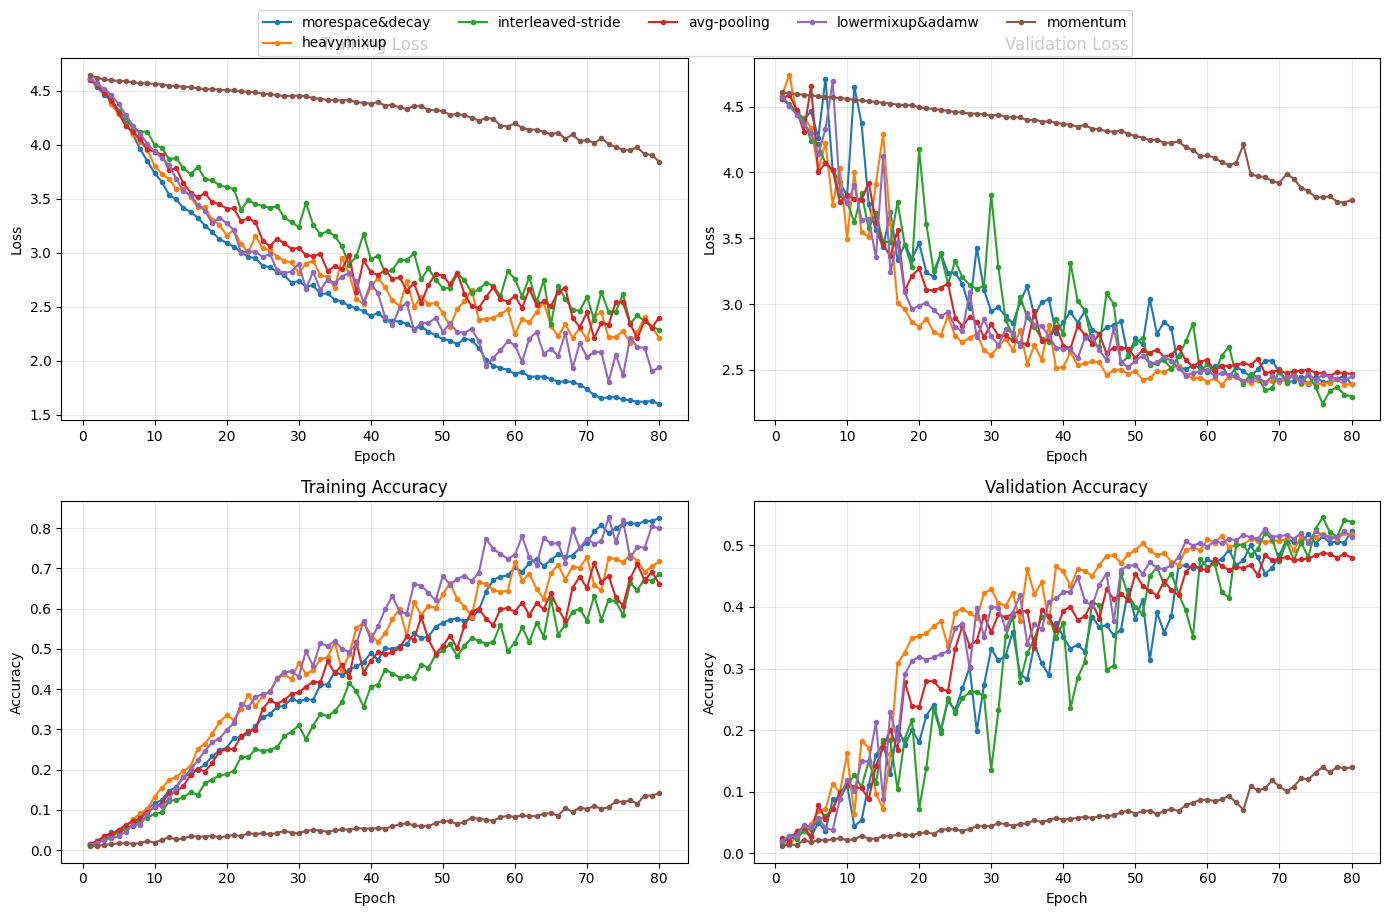

In [ ]:
# results = {}

configs = [
    ("morespace&decay", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,1,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-3,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("heavymixup", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            mixup_alpha=0.4,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("interleaved-stride", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,2,1,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            mixup_alpha=0.4,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("avg-pooling", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='avg',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            mixup_alpha=0.4,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("lowermixup&adamw", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            optimizer="AdamW",
            label_smoothing=0.1,
            mixup_alpha=0.3,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("momentum", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            epochs=80,
            learning_rate=0.001,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            optimizer="SGD",
            momentum=0.9,
            label_smoothing=0.1,
            mixup_alpha=0.3,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
        
]


for name, c in configs:
    _, history = train(
        Cnn(c.model),
        split_validation=True,
        config=c.train,
        device=DEVICE
    )
    results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }




# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

Total parameters: 499,357
epoch 1/120 loss=4.6336 accuracy=0.0051 val_loss=4.5854 val_accuracy=0.0117 time=74.3s eta=147.3min
epoch 2/120 loss=4.5705 accuracy=0.0177 val_loss=4.6299 val_accuracy=0.0162 time=66.3s eta=138.3min
epoch 3/120 loss=4.5066 accuracy=0.0189 val_loss=4.6952 val_accuracy=0.0117 time=66.4s eta=134.6min
epoch 4/120 loss=4.4961 accuracy=0.0267 val_loss=4.6900 val_accuracy=0.0180 time=66.3s eta=132.1min
epoch 5/120 loss=4.4887 accuracy=0.0309 val_loss=4.4967 val_accuracy=0.0285 time=66.1s eta=130.2min
epoch 6/120 loss=4.4681 accuracy=0.0291 val_loss=4.4549 val_accuracy=0.0348 time=66.2s eta=128.5min
epoch 7/120 loss=4.4528 accuracy=0.0276 val_loss=4.4582 val_accuracy=0.0327 time=66.5s eta=127.0min
epoch 8/120 loss=4.4324 accuracy=0.0369 val_loss=4.4298 val_accuracy=0.0378 time=65.7s eta=125.5min
epoch 9/120 loss=4.4075 accuracy=0.0348 val_loss=4.6536 val_accuracy=0.0294 time=67.6s eta=124.5min
epoch 10/120 loss=4.3968 accuracy=0.0393 val_loss=4.4366 val_accuracy=0.03

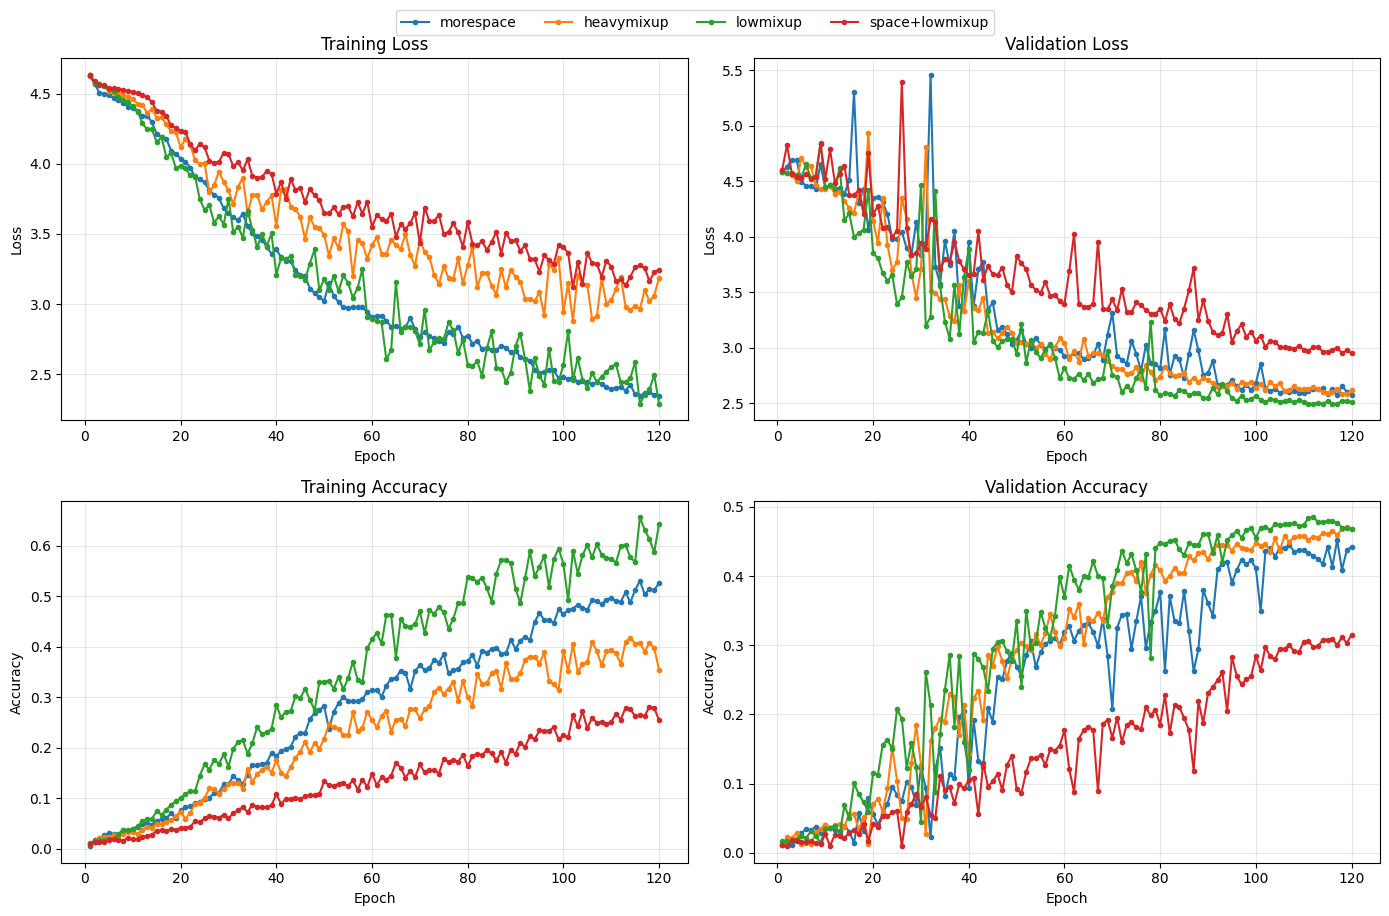

In [8]:
results = {}

configs = [
    ("morespace", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,1,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("heavymixup", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            mixup_alpha=0.4,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("lowmixup", ExpConfig(
            model=NetworkConfig(
                stem_channels=(12, 24, 48), #->32x32
                stage_channels=(48, 96, 192, 256), #->8x8
                stage_stride=(1,2,2,2),
                canonical_size=CANONICAL_SIZE,
                block_type="inception",
                classifier_hidden_dim=256,
                dropout=0.4,
                stochastic_depth=0.0,
                pooling='gem',
            ),
            train=TrainConfig(
                learning_rate=0.005,
                weight_decay=1e-4,
                scheduler="ReduceLROnPlateau",
                label_smoothing=0.1,
                mixup_alpha=0.25,
                train_transform=T.Compose([
                    T.Resize((256, 256)),
                    T.RandomHorizontalFlip(),
                    T.RandomRotation(10),
                    T.ToTensor(),
                ])
            )
        )),
    ("space+lowmixup", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,1,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            mixup_alpha=0.15,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    
]


for name, c in configs:
    _, history = train(
        Cnn(c.model),
        split_validation=True,
        epochs=120,
        config=c.train,
        device=DEVICE
    )
    results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }




# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [ ]:

configs = [
    ("mixup1", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.1,
        )
    )),
    ("mixup25", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.25,
        )
    )),
    ("mixup4", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.4,
        )
    )),
    ("wider", ExpConfig(
        model=NetworkConfig(
            stem_channels=(16, 32, 64), #->32x32
            stage_channels=(64, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),
    ("morespace", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->8x8
            stage_stride=(1,1,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
            ])
        )
    )),

]

# results = {}

for name, c in configs:
    _, history = train(
        Cnn(c.model),
        split_validation=True,
        epochs=80,
        config=c.train,
        device=DEVICE
    )
    results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }

Total parameters: 499,357
epoch 1/80 loss=4.6331 accuracy=0.0081 val_loss=4.6036 val_accuracy=0.0117 time=79.0s eta=104.0min
epoch 2/80 loss=4.5945 accuracy=0.0115 val_loss=4.5640 val_accuracy=0.0171 time=77.7s eta=101.9min
epoch 3/80 loss=4.5439 accuracy=0.0182 val_loss=4.5300 val_accuracy=0.0228 time=77.3s eta=100.1min
epoch 4/80 loss=4.5142 accuracy=0.0207 val_loss=4.5217 val_accuracy=0.0219 time=78.2s eta=98.9min
epoch 5/80 loss=4.4971 accuracy=0.0236 val_loss=4.7268 val_accuracy=0.0162 time=78.8s eta=97.8min
epoch 6/80 loss=4.4624 accuracy=0.0300 val_loss=4.4584 val_accuracy=0.0270 time=80.6s eta=97.0min
epoch 7/80 loss=4.3973 accuracy=0.0311 val_loss=4.8469 val_accuracy=0.0156 time=76.7s eta=95.3min
epoch 8/80 loss=4.3436 accuracy=0.0322 val_loss=4.2790 val_accuracy=0.0369 time=76.8s eta=93.8min
epoch 9/80 loss=4.3062 accuracy=0.0368 val_loss=4.9231 val_accuracy=0.0210 time=76.6s eta=92.3min
epoch 10/80 loss=4.2713 accuracy=0.0407 val_loss=4.3290 val_accuracy=0.0354 time=77.1s et

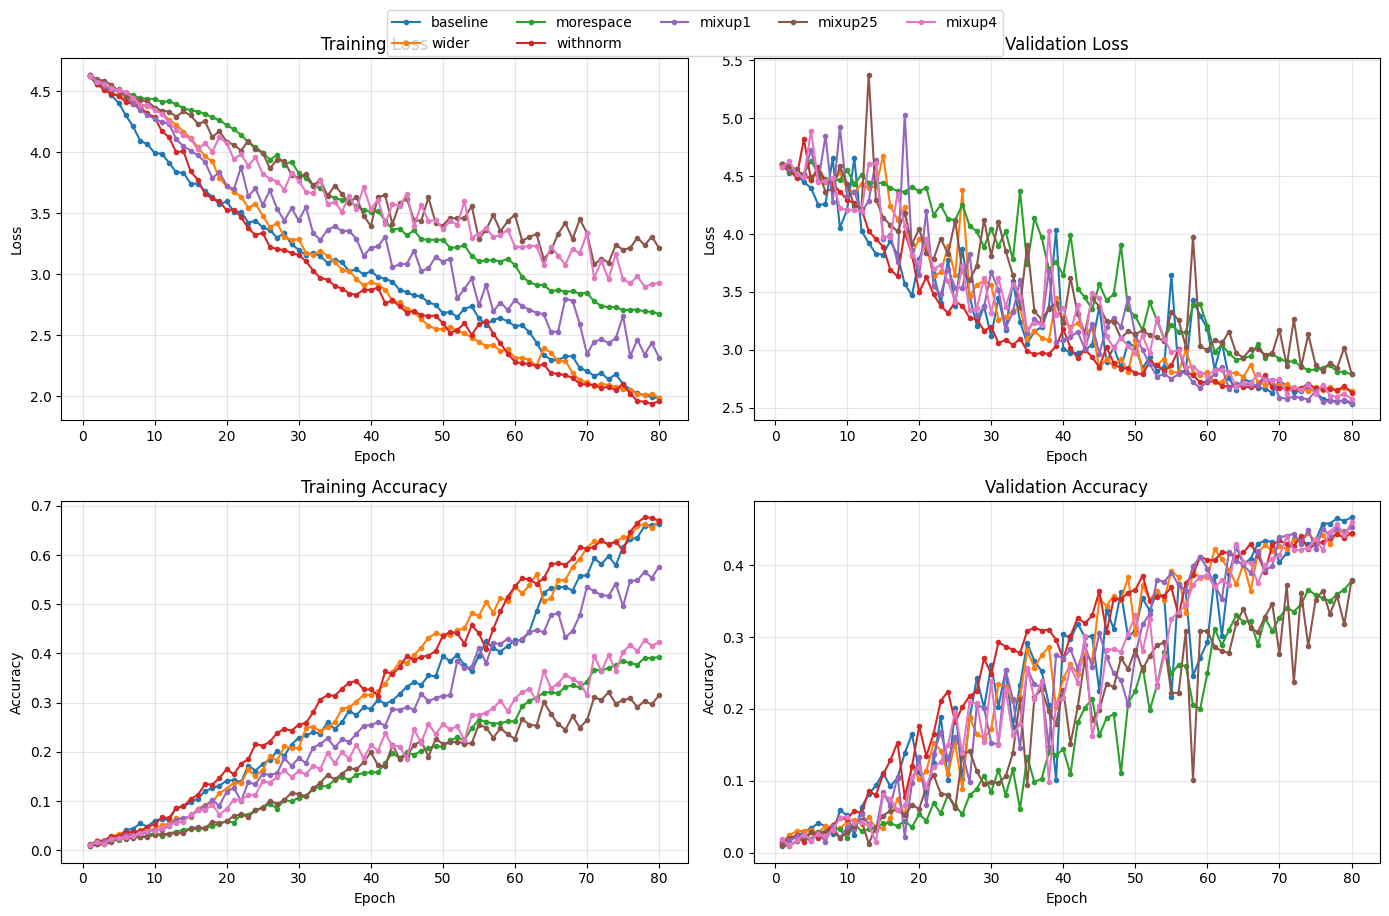

In [44]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

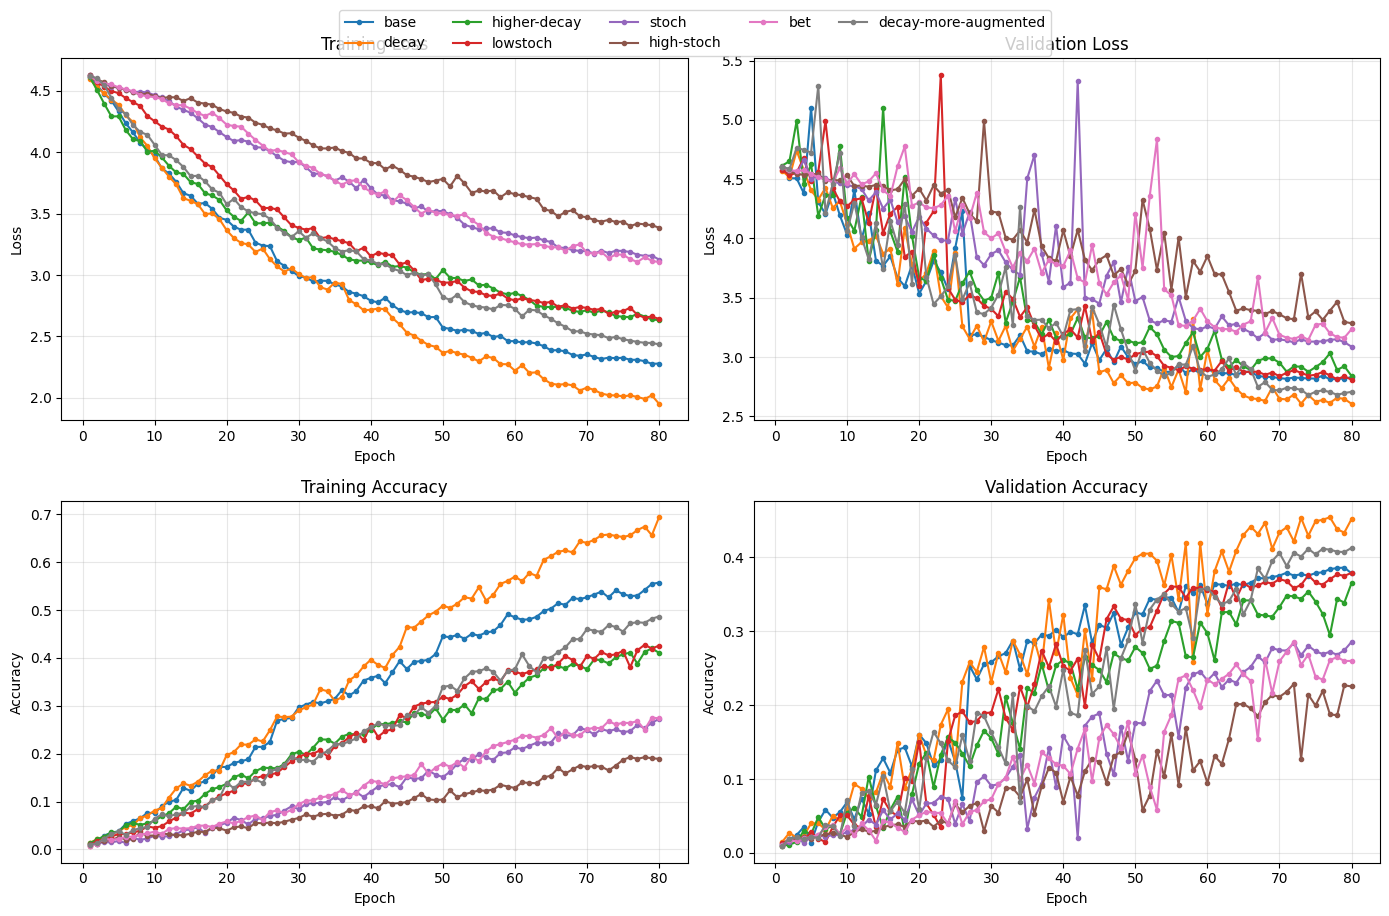

In [ ]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

#### Actual training

Here's the final proposed network. We choosed a CNN with inception modules, with the stem section taking 256x256 images and outputting 48 different 32x32 feature maps, the following feature extractor progressively increases the number of channels from 48 to the final 256, outputting 8x8 feature maps by interleaved strides. The hidden dimension of the linear classifier is matched to the number of channels and kept at 256 and internally it uses GeM pooling.
The size of the network ends up being just half a million parameters.

We train this network for 100 epochs, using a 0.4 probability of dropout, a 0.1 label smoothing coefficient, a 1e-4 factor for weight decay, and a mixup coefficient of 0.4 (with an hardcoded probability of mixup of 50%), on top of a random horizontal flip and a rotation of 10 degrees as data augmentation.

Total parameters: 499,357
epoch 1/100 loss=4.6174 accuracy=0.0122 val_loss=4.5888 val_accuracy=0.0198 time=69.6s eta=114.8min
epoch 2/100 loss=4.5788 accuracy=0.0210 val_loss=4.5618 val_accuracy=0.0189 time=69.3s eta=113.4min
epoch 3/100 loss=4.5112 accuracy=0.0281 val_loss=4.4394 val_accuracy=0.0378 time=69.2s eta=112.1min
epoch 4/100 loss=4.4476 accuracy=0.0340 val_loss=4.3475 val_accuracy=0.0465 time=69.5s eta=111.0min
epoch 5/100 loss=4.3927 accuracy=0.0365 val_loss=4.3086 val_accuracy=0.0360 time=69.6s eta=109.9min
epoch 6/100 loss=4.3253 accuracy=0.0383 val_loss=4.3159 val_accuracy=0.0357 time=69.5s eta=108.8min
epoch 7/100 loss=4.2299 accuracy=0.0554 val_loss=4.2388 val_accuracy=0.0474 time=69.3s eta=107.6min
epoch 8/100 loss=4.1642 accuracy=0.0650 val_loss=4.3976 val_accuracy=0.0465 time=69.0s eta=106.4min
epoch 9/100 loss=4.0791 accuracy=0.0755 val_loss=4.0478 val_accuracy=0.0648 time=68.8s eta=105.1min
epoch 10/100 loss=3.9979 accuracy=0.0824 val_loss=4.0342 val_accuracy=0.07

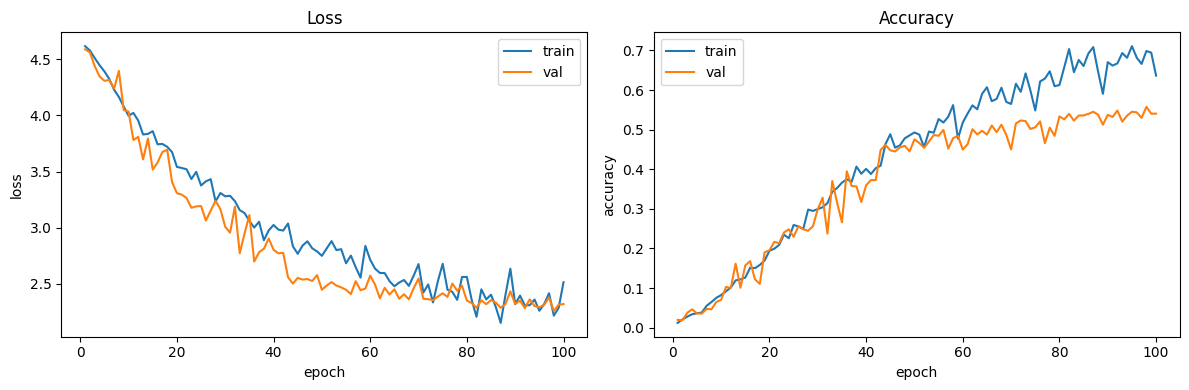

In [ ]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192, 256), #->8x8
        stage_stride=(1,2,1,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=256,
        dropout=0.4,
        stochastic_depth=0.0,
        pooling='gem',
    ),
    train=TrainConfig(
        epochs=100,
        learning_rate=0.001,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau",
        label_smoothing=0.1,
        mixup_alpha=0.4,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ])
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="submission"
)
plot_results(history)

This network is quite regularized and it shows up in the loss and accuracy trends by how close together train and validation performance are. Throughout most of the training validation loss is actually lower than the training one and the accuracies are always similar.
In the final epochs of training training loss catches up with the validation one and on the accuracy side a clear gap starts to show up, with training accuracy touching 70%, while the vaildation one remains under 60%.

Regardless, with the set target at 50% test accuracy this training recipe was considered enough, even though we believe that playing around with the regularization knobs it is still possible to get to higher accuracies with this network

##### roba vecchia

Total parameters: 225,244
epoch 1/50 loss=4.5640 accuracy=0.0172 val_loss=4.4663 val_accuracy=0.0267 time=103.5s eta=84.5min
epoch 2/50 loss=4.3757 accuracy=0.0393 val_loss=4.3862 val_accuracy=0.0387 time=103.1s eta=82.7min
epoch 3/50 loss=4.1217 accuracy=0.0507 val_loss=4.9975 val_accuracy=0.0177 time=103.1s eta=80.9min
epoch 4/50 loss=3.9581 accuracy=0.0688 val_loss=3.9023 val_accuracy=0.0882 time=102.5s eta=79.0min
epoch 5/50 loss=3.7905 accuracy=0.0999 val_loss=4.0864 val_accuracy=0.0708 time=102.0s eta=77.1min
epoch 6/50 loss=3.6589 accuracy=0.1191 val_loss=3.8460 val_accuracy=0.0921 time=103.0s eta=75.4min
epoch 7/50 loss=3.5564 accuracy=0.1380 val_loss=3.8819 val_accuracy=0.0996 time=103.6s eta=73.8min
epoch 8/50 loss=3.4655 accuracy=0.1539 val_loss=4.1025 val_accuracy=0.0690 time=103.0s eta=72.1min
epoch 9/50 loss=3.3425 accuracy=0.1837 val_loss=3.9043 val_accuracy=0.0849 time=102.4s eta=70.3min
epoch 10/50 loss=3.2987 accuracy=0.1954 val_loss=3.3254 val_accuracy=0.1977 time=10

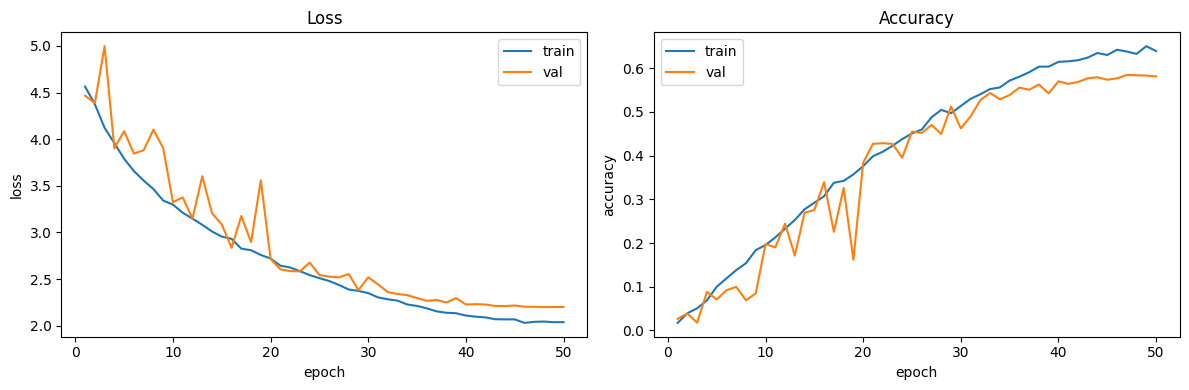

In [ ]:
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

In [9]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=100,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 225,244
epoch 1/100 loss=4.5726 accuracy=0.0139 val_loss=4.4990 val_accuracy=0.0195 time=103.8s eta=171.2min
epoch 2/100 loss=4.4613 accuracy=0.0225 val_loss=4.6832 val_accuracy=0.0150 time=107.3s eta=172.4min
epoch 3/100 loss=4.3047 accuracy=0.0387 val_loss=4.8430 val_accuracy=0.0216 time=104.2s eta=169.9min
epoch 4/100 loss=4.1109 accuracy=0.0543 val_loss=4.0602 val_accuracy=0.0579 time=104.2s eta=167.8min
epoch 5/100 loss=3.9778 accuracy=0.0727 val_loss=4.1053 val_accuracy=0.0651 time=104.0s eta=165.8min
epoch 6/100 loss=3.7973 accuracy=0.0892 val_loss=4.5476 val_accuracy=0.0453 time=103.4s eta=163.7min
epoch 7/100 loss=3.6963 accuracy=0.1119 val_loss=3.9464 val_accuracy=0.0783 time=104.2s eta=161.9min
epoch 8/100 loss=3.5943 accuracy=0.1219 val_loss=3.6591 val_accuracy=0.1326 time=103.2s eta=159.9min
epoch 9/100 loss=3.5134 accuracy=0.1435 val_loss=3.4962 val_accuracy=0.1470 time=103.5s eta=158.1min
epoch 10/100 loss=3.4172 accuracy=0.1666 val_l

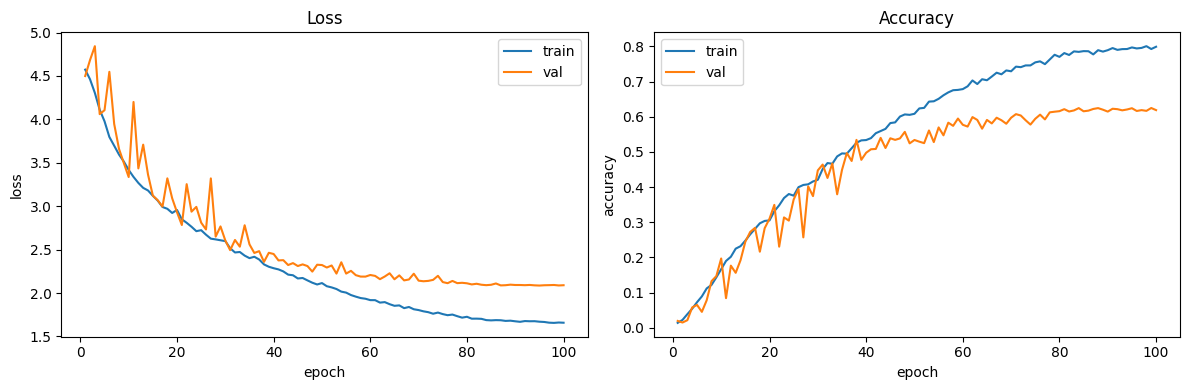

In [10]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


In [14]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(16, 32, 64), #->32x32
    stage_channels=(64, 128, 256), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=60,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 390,660
epoch 1/60 loss=4.5723 accuracy=0.0151 val_loss=4.5335 val_accuracy=0.0171 time=108.3s eta=106.5min
epoch 2/60 loss=4.4905 accuracy=0.0196 val_loss=4.4524 val_accuracy=0.0267 time=108.0s eta=104.5min
epoch 3/60 loss=4.4103 accuracy=0.0330 val_loss=4.3388 val_accuracy=0.0345 time=106.8s eta=102.3min
epoch 4/60 loss=4.2230 accuracy=0.0412 val_loss=4.9183 val_accuracy=0.0201 time=109.9s eta=101.0min
epoch 5/60 loss=3.9844 accuracy=0.0661 val_loss=3.9700 val_accuracy=0.0750 time=110.6s eta=99.7min
epoch 6/60 loss=3.8238 accuracy=0.0859 val_loss=4.6553 val_accuracy=0.0270 time=107.5s eta=97.7min
epoch 7/60 loss=3.6998 accuracy=0.1066 val_loss=3.8104 val_accuracy=0.0906 time=105.1s eta=95.4min
epoch 8/60 loss=3.5795 accuracy=0.1320 val_loss=3.9282 val_accuracy=0.0816 time=104.9s eta=93.3min
epoch 9/60 loss=3.4837 accuracy=0.1557 val_loss=4.2358 val_accuracy=0.0666 time=104.2s eta=91.2min
epoch 10/60 loss=3.3658 accuracy=0.1851 val_loss=3.7577 val_

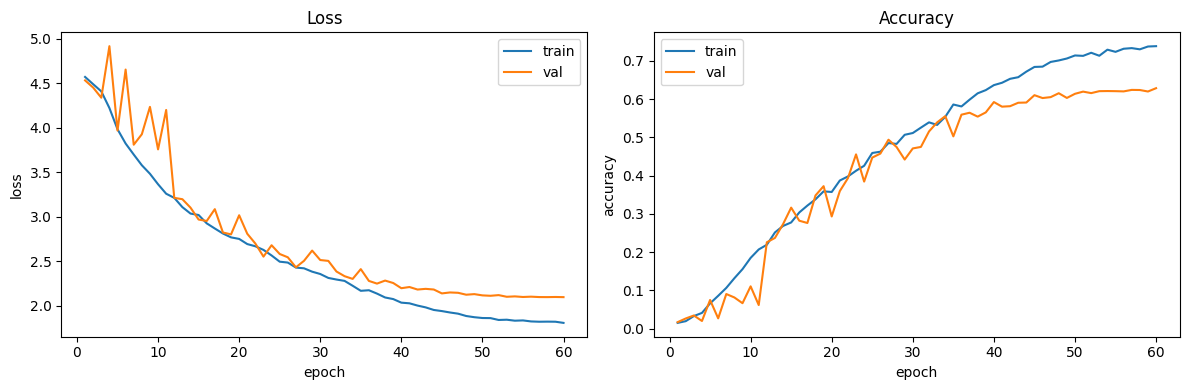

In [15]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


##### scale down

Total parameters: 71,644
epoch 1/50 loss=4.5938 accuracy=0.0159 val_loss=4.5839 val_accuracy=0.0183 time=106.3s eta=86.8min
epoch 2/50 loss=4.5199 accuracy=0.0249 val_loss=4.5421 val_accuracy=0.0252 time=103.0s eta=83.7min
epoch 3/50 loss=4.4674 accuracy=0.0286 val_loss=4.5332 val_accuracy=0.0309 time=102.9s eta=81.5min
epoch 4/50 loss=4.4349 accuracy=0.0343 val_loss=4.6298 val_accuracy=0.0306 time=103.2s eta=79.6min
epoch 5/50 loss=4.3784 accuracy=0.0423 val_loss=4.4134 val_accuracy=0.0399 time=105.6s eta=78.1min
epoch 6/50 loss=4.2650 accuracy=0.0495 val_loss=4.2528 val_accuracy=0.0600 time=102.9s eta=76.3min
epoch 7/50 loss=4.0998 accuracy=0.0621 val_loss=4.5208 val_accuracy=0.0387 time=102.6s eta=74.4min
epoch 8/50 loss=3.9857 accuracy=0.0735 val_loss=3.9051 val_accuracy=0.0879 time=102.6s eta=72.5min
epoch 9/50 loss=3.9074 accuracy=0.0870 val_loss=3.9065 val_accuracy=0.0927 time=102.7s eta=70.8min
epoch 10/50 loss=3.8290 accuracy=0.0967 val_loss=4.0020 val_accuracy=0.0699 time=101

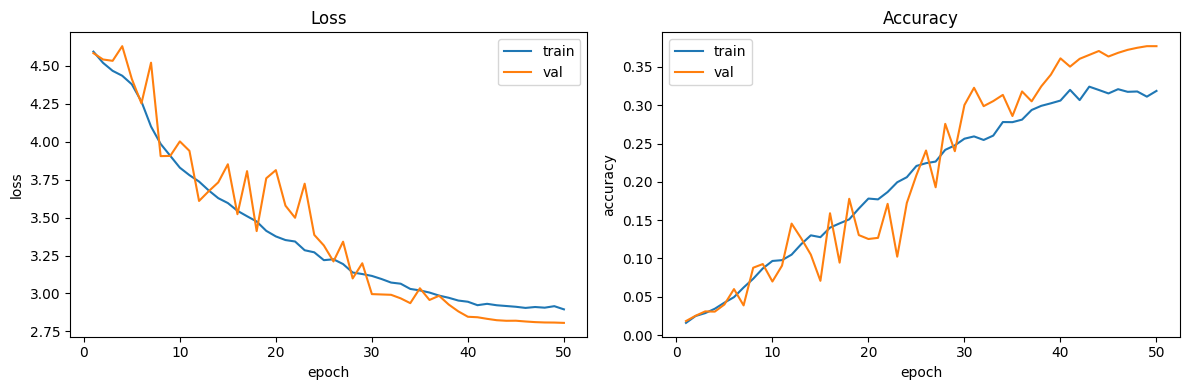

In [13]:
# -1 layer
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96), #->8x8
    stage_stride=(2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=96,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

Total parameters: 132,372
epoch 1/50 loss=4.5760 accuracy=0.0183 val_loss=4.5360 val_accuracy=0.0186 time=99.3s eta=81.1min
epoch 2/50 loss=4.5069 accuracy=0.0252 val_loss=4.5011 val_accuracy=0.0282 time=98.7s eta=79.2min
epoch 3/50 loss=4.4753 accuracy=0.0265 val_loss=4.4491 val_accuracy=0.0363 time=98.8s eta=77.5min
epoch 4/50 loss=4.4163 accuracy=0.0316 val_loss=4.3868 val_accuracy=0.0363 time=98.9s eta=75.8min
epoch 5/50 loss=4.3279 accuracy=0.0423 val_loss=4.4781 val_accuracy=0.0261 time=99.3s eta=74.2min
epoch 6/50 loss=4.2117 accuracy=0.0465 val_loss=4.6884 val_accuracy=0.0324 time=98.7s eta=72.6min
epoch 7/50 loss=4.1129 accuracy=0.0616 val_loss=4.1579 val_accuracy=0.0450 time=99.2s eta=70.9min
epoch 8/50 loss=4.0222 accuracy=0.0688 val_loss=4.2067 val_accuracy=0.0672 time=98.6s eta=69.2min
epoch 9/50 loss=3.9239 accuracy=0.0772 val_loss=4.2830 val_accuracy=0.0516 time=99.3s eta=67.6min
epoch 10/50 loss=3.8532 accuracy=0.0871 val_loss=4.0596 val_accuracy=0.0726 time=99.3s eta=6

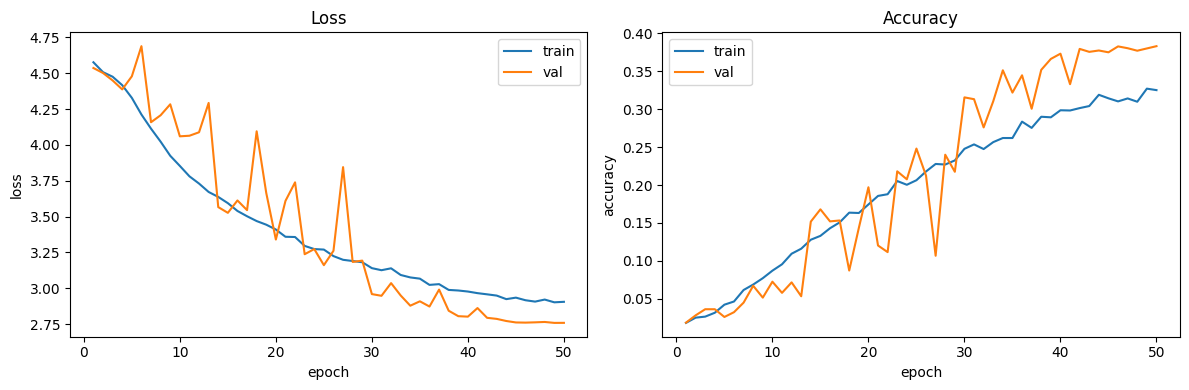

In [14]:
# -1 layer ma largo
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(96, 128), #->8x8
    stage_stride=(2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=128,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

Total parameters: 89,916
epoch 1/50 loss=4.5728 accuracy=0.0172 val_loss=4.5356 val_accuracy=0.0252 time=98.2s eta=80.2min
epoch 2/50 loss=4.4759 accuracy=0.0262 val_loss=4.4912 val_accuracy=0.0279 time=98.6s eta=78.7min
epoch 3/50 loss=4.3612 accuracy=0.0340 val_loss=4.3516 val_accuracy=0.0375 time=98.4s eta=77.1min
epoch 4/50 loss=4.2154 accuracy=0.0499 val_loss=4.4789 val_accuracy=0.0345 time=98.5s eta=75.5min
epoch 5/50 loss=4.0695 accuracy=0.0598 val_loss=4.1579 val_accuracy=0.0483 time=98.9s eta=73.9min
epoch 6/50 loss=3.9337 accuracy=0.0757 val_loss=3.8732 val_accuracy=0.0909 time=98.6s eta=72.3min
epoch 7/50 loss=3.8207 accuracy=0.0873 val_loss=4.2191 val_accuracy=0.0543 time=99.1s eta=70.7min
epoch 8/50 loss=3.7029 accuracy=0.1015 val_loss=3.8881 val_accuracy=0.0864 time=98.5s eta=69.0min
epoch 9/50 loss=3.6310 accuracy=0.1225 val_loss=4.1312 val_accuracy=0.0831 time=98.4s eta=67.4min
epoch 10/50 loss=3.5509 accuracy=0.1324 val_loss=3.5007 val_accuracy=0.1524 time=98.1s eta=65

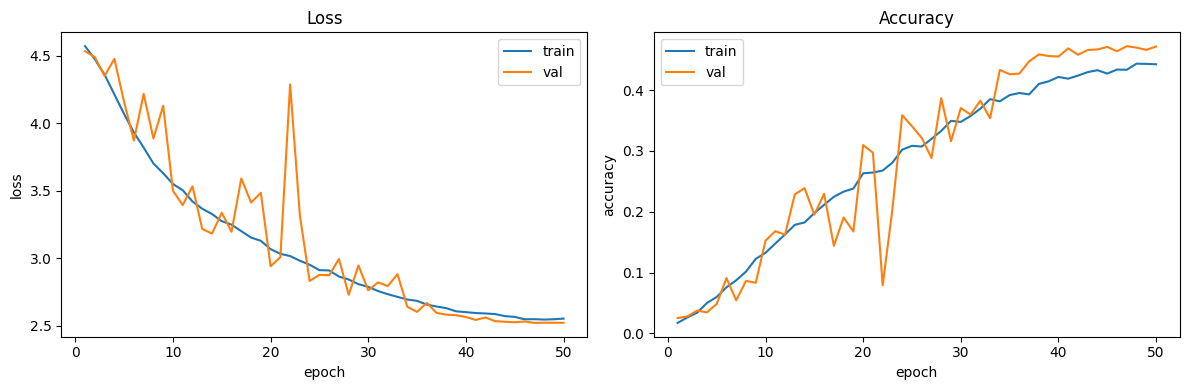

In [15]:
# magro
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 64, 96), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=96,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

### Ablation

The proposed network reaches 50% validation accuracy by epoch 62 and after epoch 80 it never dips under 50% again; because of this we decided to cap ablation runs at 80 epochs and compare with what the baseline achieved by then.

Note that, since the defaults for configuration dataclasses has been set to the proposed architecture, the only configuration parameters set in the following code cells are the specific changes made to the submission's recipe

#### No basic regularization

Total parameters: 499,357
epoch 1/80 loss=4.6156 accuracy=0.0125 val_loss=4.5898 val_accuracy=0.0144 time=67.8s eta=89.3min
epoch 2/80 loss=4.5549 accuracy=0.0204 val_loss=4.5755 val_accuracy=0.0210 time=67.7s eta=88.1min
epoch 3/80 loss=4.4389 accuracy=0.0278 val_loss=4.6498 val_accuracy=0.0192 time=67.8s eta=87.0min
epoch 4/80 loss=4.3152 accuracy=0.0436 val_loss=4.3199 val_accuracy=0.0372 time=67.6s eta=85.8min
epoch 5/80 loss=4.1465 accuracy=0.0645 val_loss=4.7299 val_accuracy=0.0264 time=67.7s eta=84.7min
epoch 6/80 loss=4.0882 accuracy=0.0709 val_loss=4.7042 val_accuracy=0.0387 time=67.7s eta=83.5min
epoch 7/80 loss=4.0179 accuracy=0.0812 val_loss=4.2748 val_accuracy=0.0480 time=67.5s eta=82.4min
epoch 8/80 loss=3.8128 accuracy=0.0971 val_loss=3.8578 val_accuracy=0.0705 time=70.5s eta=81.7min
epoch 9/80 loss=3.6811 accuracy=0.1241 val_loss=3.5207 val_accuracy=0.1122 time=70.9s eta=80.9min
epoch 10/80 loss=3.6136 accuracy=0.1381 val_loss=3.9047 val_accuracy=0.0699 time=72.6s eta=8

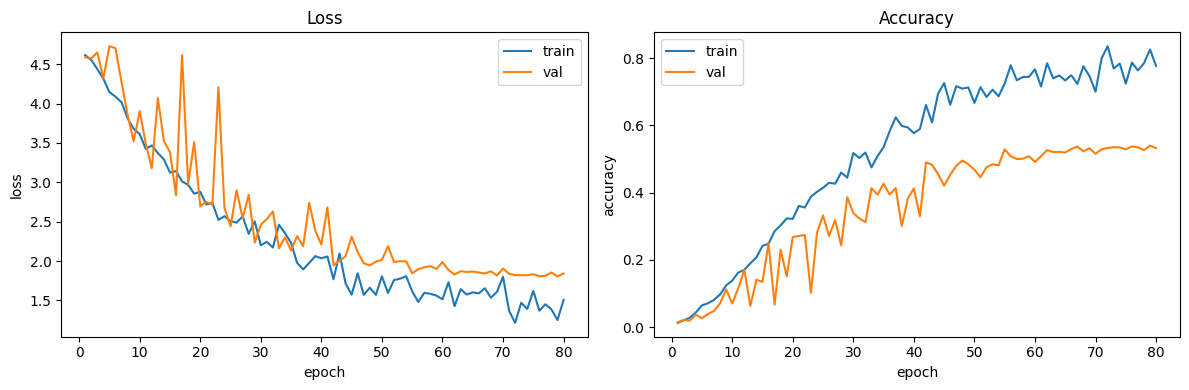

In [ ]:
config = ExpConfig(
    model=NetworkConfig(
        dropout=0.0,
    ),
    train=TrainConfig(
        epochs=80,
        label_smoothing=0.0,
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="no-reg"
)
plot_results(history)

Removing basic regularization like dropout and label smoothing doesn't show a big margin between the accuracies: the 0.09% difference between 53.35 and 53.26 can just be attributed to noise more than anything, which we mainly attribute to the strong effects of mixup and data augmentation. However, we can still observe a much more noisy plot on the validation side, both in the loss and in the accuracy, and a real gap between train and validation accuracies starting to form from the very beginning instead of the earlier epochs

#### No schedule at all

As a sane starting point we implemented ReduceLROnPlateau as a schedule for our learning rate so as to not work with a single fixed rate. However, given the heavy regularization used, validation loss stays very close to the training one in the first ~100 epochs and one might wonder if it's worth to even bother

Total parameters: 499,357
epoch 1/80 loss=4.6102 accuracy=0.0156 val_loss=4.5678 val_accuracy=0.0201 time=73.0s eta=96.1min
epoch 2/80 loss=4.5551 accuracy=0.0244 val_loss=4.5260 val_accuracy=0.0291 time=72.9s eta=94.8min
epoch 3/80 loss=4.5118 accuracy=0.0273 val_loss=4.5332 val_accuracy=0.0276 time=73.2s eta=93.7min
epoch 4/80 loss=4.4950 accuracy=0.0282 val_loss=4.4610 val_accuracy=0.0351 time=72.9s eta=92.4min
epoch 5/80 loss=4.4621 accuracy=0.0318 val_loss=4.3952 val_accuracy=0.0435 time=74.1s eta=91.5min
epoch 6/80 loss=4.4075 accuracy=0.0391 val_loss=4.4604 val_accuracy=0.0360 time=71.9s eta=90.0min
epoch 7/80 loss=4.3820 accuracy=0.0458 val_loss=4.5891 val_accuracy=0.0246 time=72.1s eta=88.7min
epoch 8/80 loss=4.2845 accuracy=0.0582 val_loss=4.5808 val_accuracy=0.0297 time=72.5s eta=87.4min
epoch 9/80 loss=4.2171 accuracy=0.0704 val_loss=4.2504 val_accuracy=0.0588 time=72.9s eta=86.2min
epoch 10/80 loss=4.0981 accuracy=0.0817 val_loss=3.8632 val_accuracy=0.1149 time=72.9s eta=8

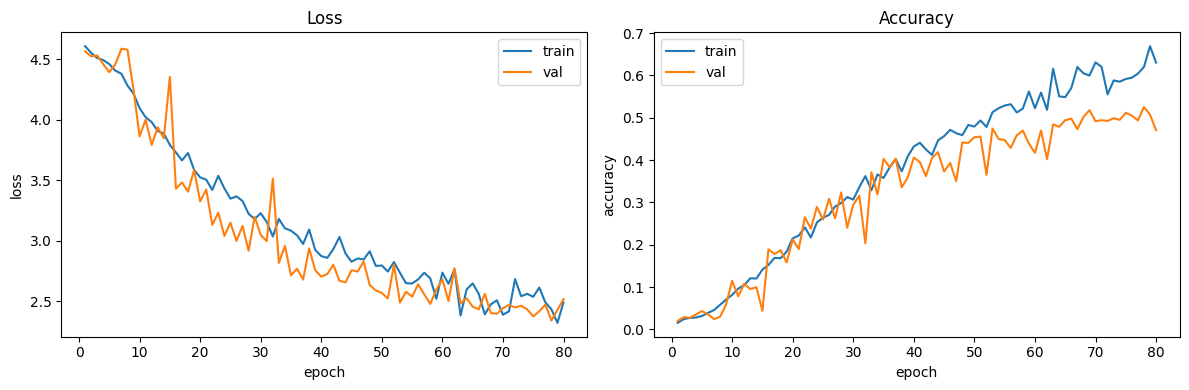

In [ ]:
config = ExpConfig(
    model=NetworkConfig(),
    train=TrainConfig(
        epochs=80,
        scheduler=None,
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="no-schedule"
)
plot_results(history)

At epoch 80 the network trained with no scheduling at all gets a comparable performance, although slightly worse. The first time a validation accuracy of >50% is reached is at epochs 68 (compared to epoch 62 for the proposed solution) and at epoch 80 it still dips below 50% (47.04% vs 53.35%).

While here the performance changes just slightly, pushing for more epochs with no scheduling on the learning rate, assuming one wants to push the accuracy further from the 50% threshold, is likely to cause a bigger gap than the one observed here.

#### No augmentation

The training split of the dataset is quite small (it contains ~3000 images) with airplane differentiating by very tiny details. Performing even minimal data augmentation by small rotations and flipping the image horizontally greatly helps

Total parameters: 499,357
epoch 1/80 loss=4.6160 accuracy=0.0093 val_loss=4.5889 val_accuracy=0.0186 time=65.8s eta=86.6min
epoch 2/80 loss=4.5692 accuracy=0.0210 val_loss=4.5532 val_accuracy=0.0192 time=65.8s eta=85.6min
epoch 3/80 loss=4.5134 accuracy=0.0238 val_loss=4.5347 val_accuracy=0.0189 time=66.5s eta=84.7min
epoch 4/80 loss=4.4591 accuracy=0.0319 val_loss=5.0462 val_accuracy=0.0168 time=67.6s eta=84.2min
epoch 5/80 loss=4.3885 accuracy=0.0388 val_loss=4.3908 val_accuracy=0.0324 time=68.2s eta=83.5min
epoch 6/80 loss=4.3006 accuracy=0.0460 val_loss=4.2637 val_accuracy=0.0528 time=66.4s eta=82.3min
epoch 7/80 loss=4.2243 accuracy=0.0661 val_loss=4.2545 val_accuracy=0.0504 time=67.1s eta=81.2min
epoch 8/80 loss=4.0997 accuracy=0.0771 val_loss=4.1689 val_accuracy=0.0573 time=69.5s eta=80.5min
epoch 9/80 loss=3.9832 accuracy=0.0913 val_loss=3.9873 val_accuracy=0.0819 time=66.6s eta=79.4min
epoch 10/80 loss=3.9957 accuracy=0.0985 val_loss=3.9865 val_accuracy=0.0699 time=66.7s eta=7

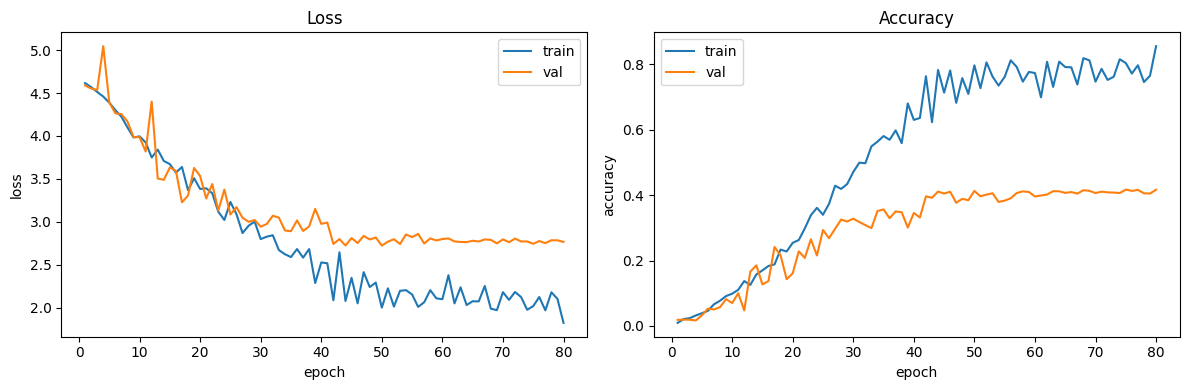

In [ ]:
config = ExpConfig(
    model=NetworkConfig(),
    train=TrainConfig(
        epochs=80,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.ToTensor(),
        ])
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="no-augmentation"
)
plot_results(history)

Without any data augmentation this network stops learning around epoch 45, where the validation performance plateaus. After that the network is still able to improve performance on the training set, but fails to generalize to the validation. Learning also slows down on the training set probably because of subsequent triggers of the schedule progressively reducing the learning each ~5 epochs. The final accuracy achieved by this network on the test set is of just 43.59%, almost 10% less than the proposed solution and below the target accuracy of 50%

#### No mixup

Mixup is another strong regularizer we employed and we validate its effectiveness here

Total parameters: 499,357
epoch 1/80 loss=4.6157 accuracy=0.0159 val_loss=4.5619 val_accuracy=0.0243 time=69.7s eta=91.8min
epoch 2/80 loss=4.5271 accuracy=0.0267 val_loss=4.5154 val_accuracy=0.0270 time=69.8s eta=90.7min
epoch 3/80 loss=4.4382 accuracy=0.0333 val_loss=4.4234 val_accuracy=0.0345 time=70.1s eta=89.7min
epoch 4/80 loss=4.3128 accuracy=0.0426 val_loss=4.3210 val_accuracy=0.0549 time=69.7s eta=88.5min
epoch 5/80 loss=4.1879 accuracy=0.0588 val_loss=4.9748 val_accuracy=0.0288 time=69.6s eta=87.2min
epoch 6/80 loss=4.0643 accuracy=0.0678 val_loss=4.9091 val_accuracy=0.0345 time=69.4s eta=86.0min
epoch 7/80 loss=3.9717 accuracy=0.0834 val_loss=4.0142 val_accuracy=0.0801 time=69.5s eta=84.8min
epoch 8/80 loss=3.8581 accuracy=0.0885 val_loss=4.1609 val_accuracy=0.0624 time=69.6s eta=83.6min
epoch 9/80 loss=3.7673 accuracy=0.1146 val_loss=3.7829 val_accuracy=0.1086 time=69.0s eta=82.4min
epoch 10/80 loss=3.6510 accuracy=0.1251 val_loss=3.8572 val_accuracy=0.0942 time=71.3s eta=8

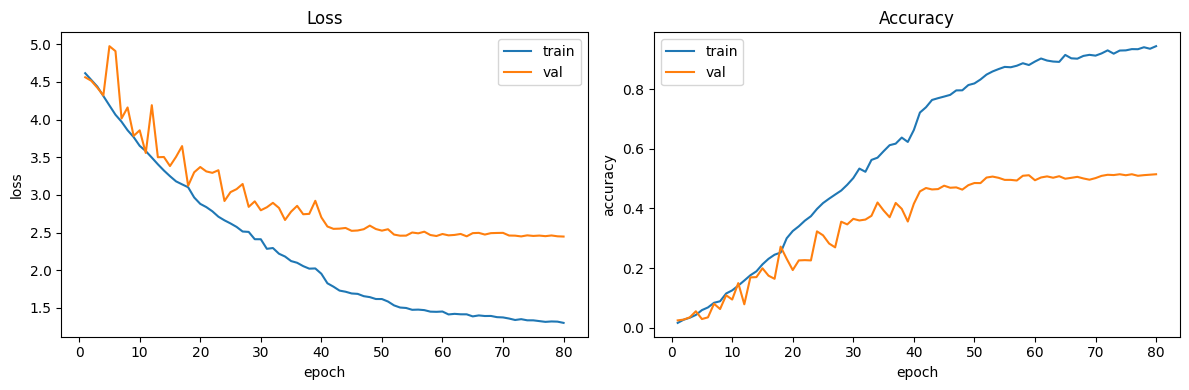

In [ ]:
config = ExpConfig(
    model=NetworkConfig(),
    train=TrainConfig(
        epochs=80,
        mixup_alpha=0.0,
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="no-mixup"
)
plot_results(history)

This training recipe finishes with a 51.61% accuracy, which would still be above the target, and gets there around epoch 55-60, stablizing there afterwards. However, it is still lower than the proposed solution by ~2%. On top of that these plots show a much bigger gap between the training and validation performance and verify that there is very little hope for higher performance to be achieved without any sort of mixup

#### Global avg pooling vs GEM pooling

It can be interesting to investigate if GeM pooling is even worth the hassle of implementing it or one is better off just using standard global average pooling. We then run this experiment to validate this

Total parameters: 499,356
epoch 1/80 loss=4.6011 accuracy=0.0138 val_loss=4.5756 val_accuracy=0.0150 time=66.8s eta=88.0min
epoch 2/80 loss=4.5444 accuracy=0.0205 val_loss=4.5381 val_accuracy=0.0216 time=67.1s eta=87.1min
epoch 3/80 loss=4.5123 accuracy=0.0266 val_loss=4.4492 val_accuracy=0.0303 time=66.7s eta=85.8min
epoch 4/80 loss=4.4577 accuracy=0.0362 val_loss=4.4227 val_accuracy=0.0336 time=66.6s eta=84.6min
epoch 5/80 loss=4.4032 accuracy=0.0426 val_loss=4.3930 val_accuracy=0.0345 time=66.8s eta=83.5min
epoch 6/80 loss=4.3492 accuracy=0.0447 val_loss=4.3814 val_accuracy=0.0369 time=67.1s eta=82.5min
epoch 7/80 loss=4.2571 accuracy=0.0569 val_loss=4.3081 val_accuracy=0.0516 time=66.9s eta=81.3min
epoch 8/80 loss=4.2055 accuracy=0.0591 val_loss=4.2087 val_accuracy=0.0555 time=67.1s eta=80.3min
epoch 9/80 loss=4.1757 accuracy=0.0734 val_loss=4.2217 val_accuracy=0.0411 time=66.7s eta=79.1min
epoch 10/80 loss=4.0240 accuracy=0.0858 val_loss=4.1145 val_accuracy=0.0702 time=66.8s eta=7

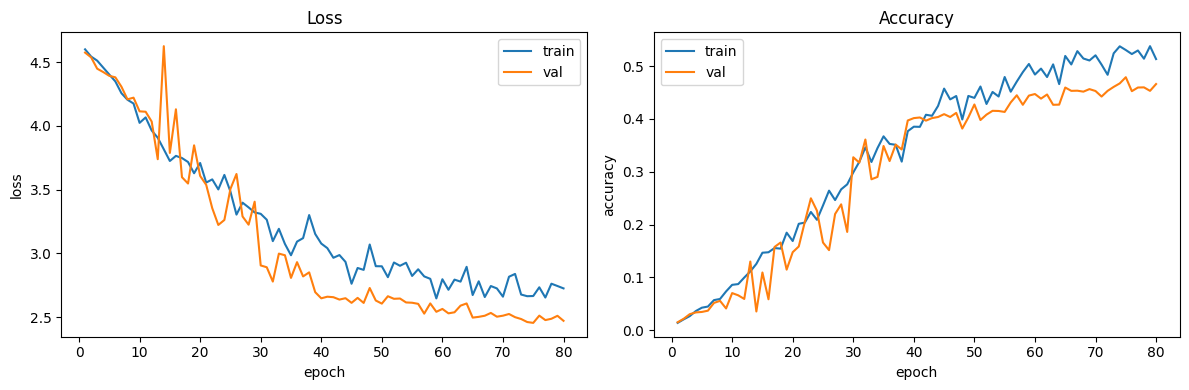

In [ ]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192, 256), #->8x8
        stage_stride=(1,2,1,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=256,
        dropout=0.4,
        stochastic_depth=0.0,
        pooling='avg',
    ),
    train=TrainConfig(
        epochs=80,
        learning_rate=0.001,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau",
        label_smoothing=0.1,
        mixup_alpha=0.4,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ])
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="avg-pooling"
)
plot_results(history)

At epoch 80% this model finishes with a validation accuracy of 46.59%, less than the 53.53% achieved by the proposed network at the same epoch, a 6.94% loss in performance. The final accuracy on the test set is 47.7%, below the set accuracy target.
However it still seems that the network is learning and possible for it to eventually surpass the 50% threshold given the time.

Looking at the plots it also appears that this might have an intrinsic regularizing effect, since the gap between validation and training performance is more favourable (at epoch 80 the proposed solution has validation accuracy lower by 7.91% than the training one, while with global average pooling the gap is just of 4.73%).

#### Lower learning rate

One might find a learning rate of 0.001 to be somewhat high for an Adam optimizer. However we validated that it does not prevent convergence across multiple training runs during development and here we verify that setting a lower one actually makes the network much slower to train

Total parameters: 499,357
epoch 1/80 loss=4.6291 accuracy=0.0108 val_loss=4.6004 val_accuracy=0.0117 time=70.1s eta=92.3min
epoch 2/80 loss=4.5983 accuracy=0.0131 val_loss=4.5804 val_accuracy=0.0192 time=70.6s eta=91.5min
epoch 3/80 loss=4.5795 accuracy=0.0218 val_loss=4.5590 val_accuracy=0.0243 time=70.7s eta=90.4min
epoch 4/80 loss=4.5606 accuracy=0.0231 val_loss=4.5419 val_accuracy=0.0246 time=70.0s eta=89.1min
epoch 5/80 loss=4.5476 accuracy=0.0229 val_loss=4.5258 val_accuracy=0.0258 time=69.5s eta=87.7min
epoch 6/80 loss=4.5295 accuracy=0.0270 val_loss=4.5073 val_accuracy=0.0270 time=69.2s eta=86.3min
epoch 7/80 loss=4.5211 accuracy=0.0326 val_loss=4.4899 val_accuracy=0.0300 time=68.4s eta=84.9min
epoch 8/80 loss=4.5068 accuracy=0.0306 val_loss=4.4738 val_accuracy=0.0333 time=69.8s eta=83.7min
epoch 9/80 loss=4.4992 accuracy=0.0352 val_loss=4.4607 val_accuracy=0.0378 time=68.7s eta=82.4min
epoch 10/80 loss=4.4854 accuracy=0.0338 val_loss=4.4413 val_accuracy=0.0378 time=70.0s eta=8

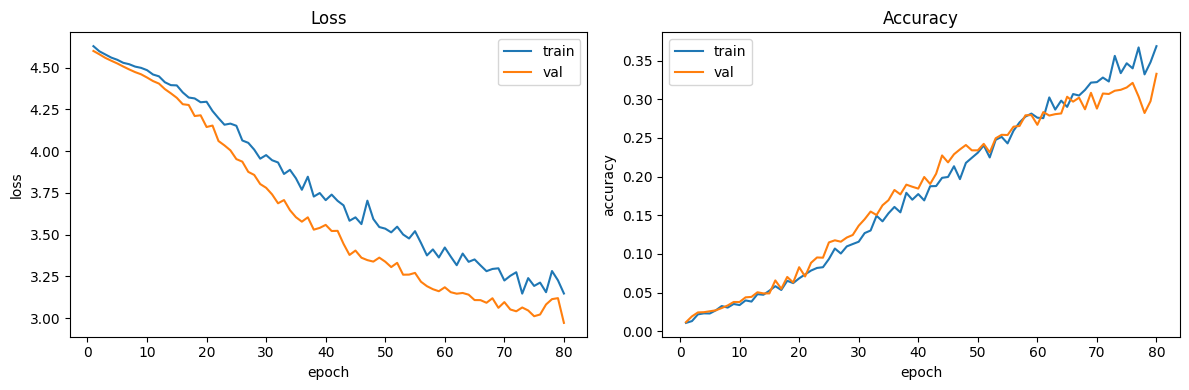

In [ ]:
config = ExpConfig(
    model=NetworkConfig(),
    train=TrainConfig(
        epochs=80,
        learning_rate=0.0001,
    )
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="less-learning-rate"
)
plot_results(history)

#### Other network configurations

During development we converged on the network architechture with 4 stages in the feature extractor, after the final solution was coded and trained and late in the ablation studies we tried cutting down the network in the following experiment. This showed that even a smaller network does indeed make the cut to the 50%. The following network is composed of on 243K parameters

Total parameters: 243,997
epoch 1/100 loss=4.6220 accuracy=0.0099 val_loss=4.5767 val_accuracy=0.0249 time=67.1s eta=110.7min
epoch 2/100 loss=4.5652 accuracy=0.0193 val_loss=4.5216 val_accuracy=0.0240 time=66.9s eta=109.4min
epoch 3/100 loss=4.5336 accuracy=0.0212 val_loss=4.4855 val_accuracy=0.0318 time=66.8s eta=108.2min
epoch 4/100 loss=4.4860 accuracy=0.0307 val_loss=4.4275 val_accuracy=0.0369 time=67.0s eta=107.1min
epoch 5/100 loss=4.4280 accuracy=0.0374 val_loss=4.6350 val_accuracy=0.0243 time=66.8s eta=105.9min
epoch 6/100 loss=4.3754 accuracy=0.0470 val_loss=4.3515 val_accuracy=0.0375 time=66.8s eta=104.8min
epoch 7/100 loss=4.3080 accuracy=0.0554 val_loss=5.0295 val_accuracy=0.0174 time=67.4s eta=103.8min
epoch 8/100 loss=4.1984 accuracy=0.0660 val_loss=3.9904 val_accuracy=0.0777 time=67.0s eta=102.7min
epoch 9/100 loss=4.1263 accuracy=0.0669 val_loss=4.1068 val_accuracy=0.0624 time=66.9s eta=101.6min
epoch 10/100 loss=4.0358 accuracy=0.0862 val_loss=4.0345 val_accuracy=0.05

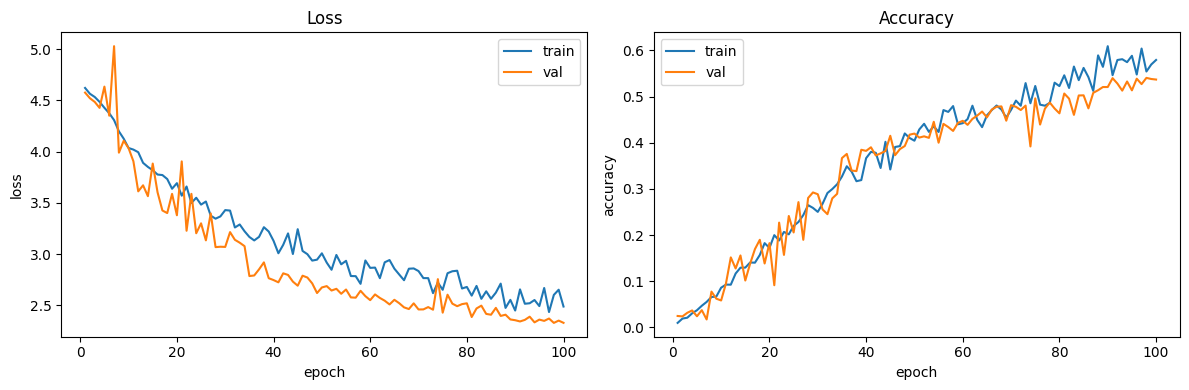

In [ ]:
config = ExpConfig(
    model=NetworkConfig(
        stage_channels=(48, 96, 192), #->16x16
        stage_stride=(1,2,1),
    ),
    train=TrainConfig()
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="less-stage"
)
plot_results(history)

Trained for the same number of epochs of the solution, this network got a 54.33% accuracy on test data, short of just 0.67% of the submission (22 photos out of the 3333 in the test split), such a small difference that could even be attributed to minimal performance variance from the randomness of training. On top of this this smaller network appears to be more regularized as the validation loss remains lower than the training one even in late training while accuracies also remain very close. We attribute this to the less likelyhood of smaller networks to overfit.

That being said cutting down yet another layer does indeed degrade performace, as we verify here

Total parameters: 103,165
epoch 1/100 loss=4.6175 accuracy=0.0110 val_loss=4.5815 val_accuracy=0.0249 time=71.9s eta=118.6min
epoch 2/100 loss=4.5637 accuracy=0.0195 val_loss=4.5291 val_accuracy=0.0234 time=70.3s eta=116.1min
epoch 3/100 loss=4.5290 accuracy=0.0240 val_loss=4.5912 val_accuracy=0.0165 time=71.8s eta=115.3min
epoch 4/100 loss=4.5010 accuracy=0.0273 val_loss=4.4678 val_accuracy=0.0291 time=71.4s eta=114.1min
epoch 5/100 loss=4.4653 accuracy=0.0372 val_loss=4.4740 val_accuracy=0.0360 time=70.6s eta=112.7min
epoch 6/100 loss=4.4391 accuracy=0.0417 val_loss=4.5097 val_accuracy=0.0249 time=69.7s eta=111.1min
epoch 7/100 loss=4.4273 accuracy=0.0359 val_loss=4.3978 val_accuracy=0.0435 time=70.9s eta=109.9min
epoch 8/100 loss=4.3791 accuracy=0.0487 val_loss=4.3766 val_accuracy=0.0522 time=70.2s eta=108.6min
epoch 9/100 loss=4.3182 accuracy=0.0578 val_loss=4.7409 val_accuracy=0.0306 time=69.5s eta=107.2min
epoch 10/100 loss=4.2600 accuracy=0.0638 val_loss=4.1404 val_accuracy=0.07

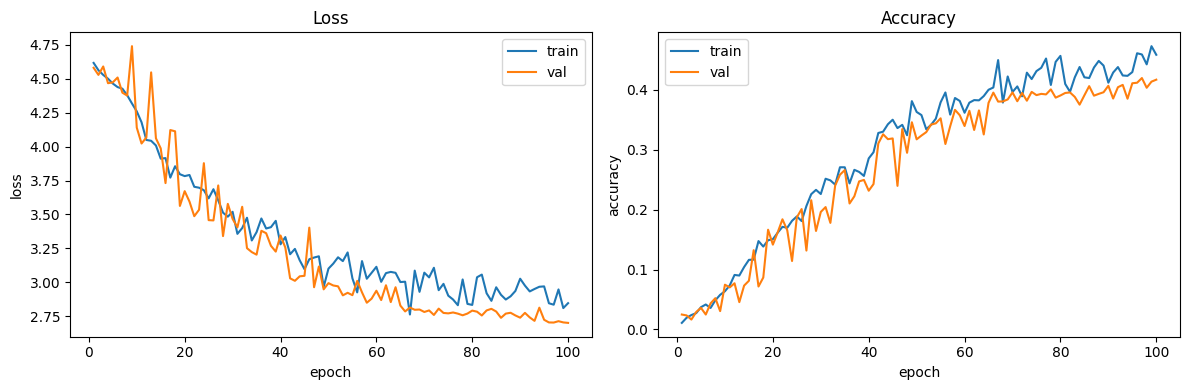

In [47]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96), #->16x16
        stage_stride=(1,2),
    ),
    train=TrainConfig()
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="less-stage-broken"
)
plot_results(history)

In [48]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48), #->32x32
        stage_stride=(1),
    ),
    train=TrainConfig()
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="less-stage-broken"
)
plot_results(history)

TypeError: object of type 'int' has no len()

In [ ]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24), #->64x64
        stage_channels=(48), #->32x32
        stage_stride=(1),
    ),
    train=TrainConfig()
)

_, history, final_loss, final_accuracy = run_experiment(
    config,
    split_validation=True,
    name="less-stage-broken"
)
plot_results(history)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

### Same parameters

In [ ]:
NUM_CLASSES = 100

def build_resnet():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


@dataclass
class FinetuneConfig:
    """Hyperparameters for the finetuning run in `finetune.py`."""

    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.0
    scheduler: Literal["ReduceLROnPlateau", "CosineAnnealingLR"] = "ReduceLROnPlateau"
    label_smoothing: float = 0.0
    train_transform: T.Compose = None
    mixup_alpha: float = 0.0
    epochs: int = 1
    split_validation: bool = True
    batch_size: int = 128


def finetune(
    model,
    device,
    config: FinetuneConfig,
):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    backbone_params = [
        p for name, p in model.named_parameters() if not name.startswith("fc.")
    ]
    head_params = list(model.fc.parameters())

    for param in backbone_params:
        param.requires_grad = config.lr_backbone != 0
    for param in head_params:
        param.requires_grad = config.lr_head != 0

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params:,}")

    train_loader, val_loader, _ = get_loaders(
        config.train_transform, config.split_validation, config.batch_size
    )

    param_groups = []
    if config.lr_backbone != 0:
        param_groups.append({"params": backbone_params, "lr": config.lr_backbone})
    if config.lr_head != 0:
        param_groups.append({"params": head_params, "lr": config.lr_head})

    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = Adam(param_groups, weight_decay=config.weight_decay)
    scheduler = get_scheduler(config.scheduler, optimizer, config.epochs)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_durations = []

    for epoch in range(config.epochs):
        start = time.perf_counter()
        train_loss, train_accuracy = _run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=device,
            mixup_alpha=config.mixup_alpha,
        )
        val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device=device)
        duration = time.perf_counter() - start
        epoch_durations.append(duration)

        if scheduler is not None:
            if config.scheduler == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            elif scheduler:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (config.epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{config.epochs} loss={train_loss:.4f} accuracy={train_accuracy:.4f} "
            f"val_loss={val_loss:.4f} val_accuracy={val_accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, history


def run_ft_experiment(
        model,
        config,
        name=None
):

    model, history = finetune(
        model=model,
        device=DEVICE,
        config=config,
    )
    print("Train run finished")

    loss, accuracy = evaluate(
        model,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )

    print("Evaluation on test set finished")
    print(f"Final loss: {loss}")
    print(f"Final accuracy: {accuracy}")

    if name:
        store_weights(name, model)
        store_results(name, history, loss, accuracy)

    return model, history, loss, accuracy



Total parameters: 11,227,812
epoch 1/100 loss=4.1683 accuracy=0.0917 val_loss=3.9717 val_accuracy=0.1038 time=78.2s eta=129.0min
epoch 2/100 loss=3.5000 accuracy=0.2211 val_loss=3.8838 val_accuracy=0.1299 time=80.0s eta=129.2min
epoch 3/100 loss=3.0962 accuracy=0.3436 val_loss=2.8244 val_accuracy=0.3405 time=79.9s eta=128.3min
epoch 4/100 loss=2.7182 accuracy=0.4470 val_loss=3.6403 val_accuracy=0.2220 time=80.6s eta=127.5min
epoch 5/100 loss=2.7560 accuracy=0.4710 val_loss=2.5352 val_accuracy=0.4332 time=80.6s eta=126.4min
epoch 6/100 loss=2.4171 accuracy=0.5674 val_loss=2.8612 val_accuracy=0.3810 time=81.6s eta=125.6min
epoch 7/100 loss=2.5236 accuracy=0.5586 val_loss=2.4552 val_accuracy=0.4794 time=82.3s eta=124.7min
epoch 8/100 loss=2.2615 accuracy=0.6358 val_loss=2.5589 val_accuracy=0.4743 time=80.9s eta=123.5min
epoch 9/100 loss=2.1034 accuracy=0.6774 val_loss=2.2091 val_accuracy=0.5710 time=83.6s eta=122.6min
epoch 10/100 loss=2.1194 accuracy=0.6820 val_loss=2.2344 val_accuracy=0

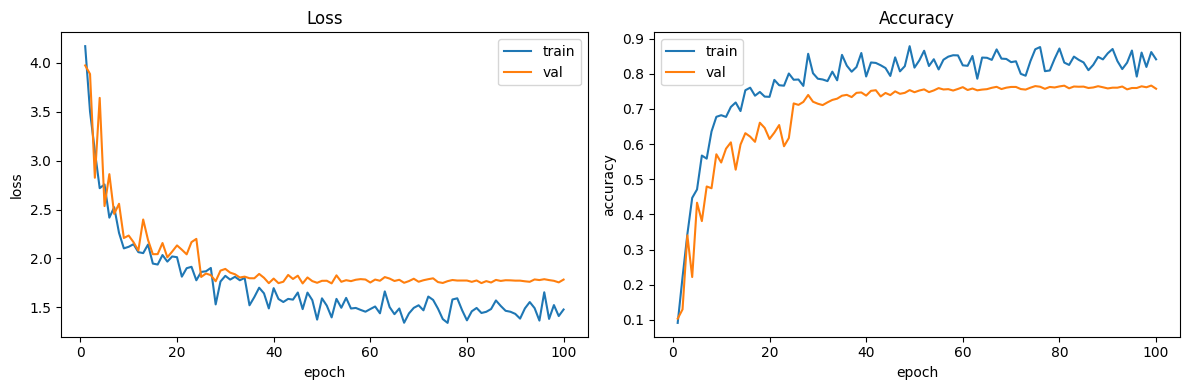

In [26]:
config = TrainConfig(
    epochs=100,
    learning_rate=0.001,
    weight_decay=1e-4,
    scheduler="ReduceLROnPlateau",
    label_smoothing=0.1,
    mixup_alpha=0.4,
    train_transform=T.Compose([
        T.Resize((256, 256)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ToTensor(),
    ])
)

resnet = build_resnet()
name = "base-resnet"


model, history = train(
    resnet,
    split_validation=True,
    device=DEVICE,
    config=config,
)
print("Train run finished")

loss, accuracy = evaluate(
    model,
    batch_size=BATCH_SIZE
)

print("Evaluation on test set finished")
print(f"Final loss: {loss}")
print(f"Final accuracy: {accuracy}")

if name:
    store_weights(name, model)
    store_results(name, history, loss, accuracy)


plot_results(history)

### sweep

Total parameters: 11,227,812
Trainable parameters: 11,227,812
epoch 1/80 loss=4.6142 accuracy=0.0333 val_loss=4.2032 val_accuracy=0.1077 time=78.6s eta=103.5min
epoch 2/80 loss=4.0506 accuracy=0.1361 val_loss=3.5470 val_accuracy=0.2103 time=78.5s eta=102.1min
epoch 3/80 loss=3.5778 accuracy=0.2252 val_loss=3.1473 val_accuracy=0.2964 time=78.8s eta=100.9min
epoch 4/80 loss=3.3258 accuracy=0.2876 val_loss=2.9386 val_accuracy=0.3381 time=78.8s eta=99.7min
epoch 5/80 loss=3.1637 accuracy=0.3405 val_loss=2.7960 val_accuracy=0.4116 time=79.1s eta=98.5min
epoch 6/80 loss=2.9520 accuracy=0.3940 val_loss=2.5753 val_accuracy=0.4353 time=78.9s eta=97.2min
epoch 7/80 loss=2.8513 accuracy=0.4300 val_loss=2.5671 val_accuracy=0.4443 time=78.8s eta=95.9min
epoch 8/80 loss=2.6970 accuracy=0.4759 val_loss=2.6663 val_accuracy=0.4317 time=79.0s eta=94.6min
epoch 9/80 loss=2.7148 accuracy=0.4913 val_loss=2.4429 val_accuracy=0.5074 time=78.9s eta=93.3min
epoch 10/80 loss=2.6771 accuracy=0.4914 val_loss=2.42

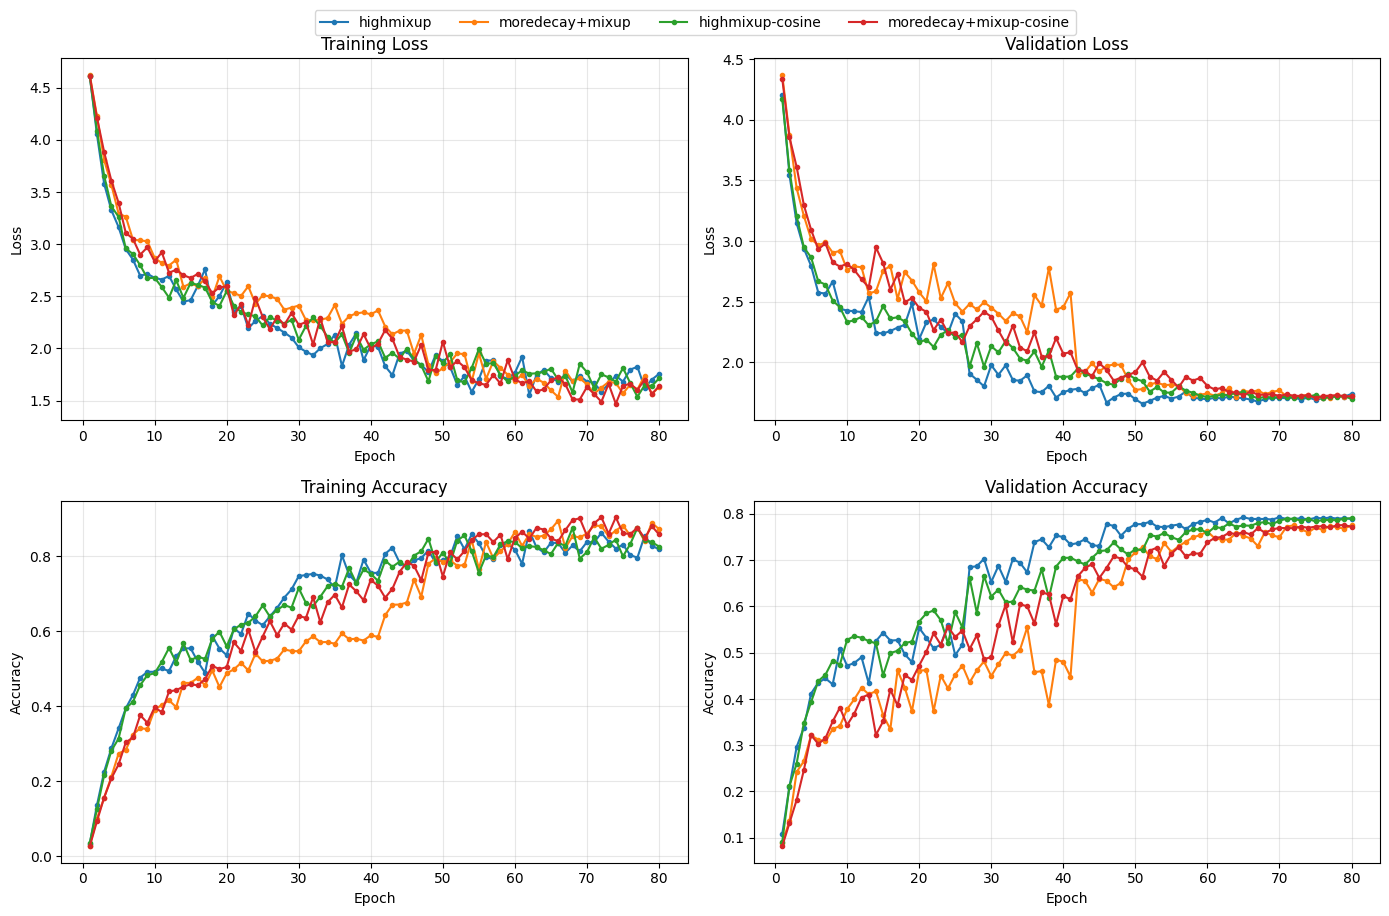

In [45]:
# comment this to preserve the previous run so they can be plot together
ft_results = {}

configs = [
    ("highmixup", FinetuneConfig(
        epochs=80,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-1,
        label_smoothing=0.1,
        mixup_alpha=0.4,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("moredecay+mixup", FinetuneConfig(
        epochs=80,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=2e-1,
        label_smoothing=0.1,
        mixup_alpha=0.2,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("highmixup-cosine", FinetuneConfig(
        epochs=80,
        scheduler="CosineAnnealingLR",
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-1,
        label_smoothing=0.1,
        mixup_alpha=0.4,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("moredecay+mixup-cosine", FinetuneConfig(
        epochs=80,
        scheduler="CosineAnnealingLR",
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=2e-1,
        label_smoothing=0.1,
        mixup_alpha=0.2,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    
]


for name, c in configs:
    resnet = build_resnet()
    _, history = finetune(
        resnet,
        device=DEVICE,
        config=c,
    )
    ft_results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }




# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(ft_results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in ft_results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(ft_results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [13]:
# comment this to preserve the previous run so they can be plot together
ft_results = {}

configs = [
    ("baseline", FinetuneConfig(
        epochs=40,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-2,
        label_smoothing=0.1,
        mixup_alpha=0.0,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("moredecay", FinetuneConfig(
        epochs=40,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-1,
        label_smoothing=0.1,
        mixup_alpha=0.0,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("lowmixup", FinetuneConfig(
        epochs=40,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-2,
        label_smoothing=0.1,
        mixup_alpha=0.1,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("higher-lr", FinetuneConfig(
        epochs=40,
        lr_backbone=1e-4,
        lr_head=4e-3,
        weight_decay=1e-2,
        label_smoothing=0.1,
        mixup_alpha=0.0,
        batch_size=64,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),

]


for name, c in configs:
    resnet = build_resnet()
    _, history = finetune(
        resnet,
        device=DEVICE,
        config=c,
    )
    ft_results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }

Total parameters: 11,227,812
Trainable parameters: 11,227,812
epoch 1/40 loss=4.2956 accuracy=0.0876 val_loss=3.5425 val_accuracy=0.2229 time=79.6s eta=51.7min
epoch 2/40 loss=3.0023 accuracy=0.3743 val_loss=2.7982 val_accuracy=0.3840 time=77.0s eta=49.6min
epoch 3/40 loss=2.3011 accuracy=0.5855 val_loss=2.3969 val_accuracy=0.4947 time=77.7s eta=48.2min
epoch 4/40 loss=1.8317 accuracy=0.7307 val_loss=2.2210 val_accuracy=0.5542 time=78.0s eta=46.8min
epoch 5/40 loss=1.5436 accuracy=0.8353 val_loss=2.0840 val_accuracy=0.6073 time=77.1s eta=45.4min
epoch 6/40 loss=1.3551 accuracy=0.8908 val_loss=2.1463 val_accuracy=0.5719 time=77.5s eta=44.1min
epoch 7/40 loss=1.2154 accuracy=0.9361 val_loss=1.9983 val_accuracy=0.6367 time=77.5s eta=42.8min
epoch 8/40 loss=1.1272 accuracy=0.9601 val_loss=1.9491 val_accuracy=0.6556 time=77.1s eta=41.4min
epoch 9/40 loss=1.0631 accuracy=0.9727 val_loss=1.9698 val_accuracy=0.6478 time=77.8s eta=40.1min
epoch 10/40 loss=1.0328 accuracy=0.9820 val_loss=1.9795 

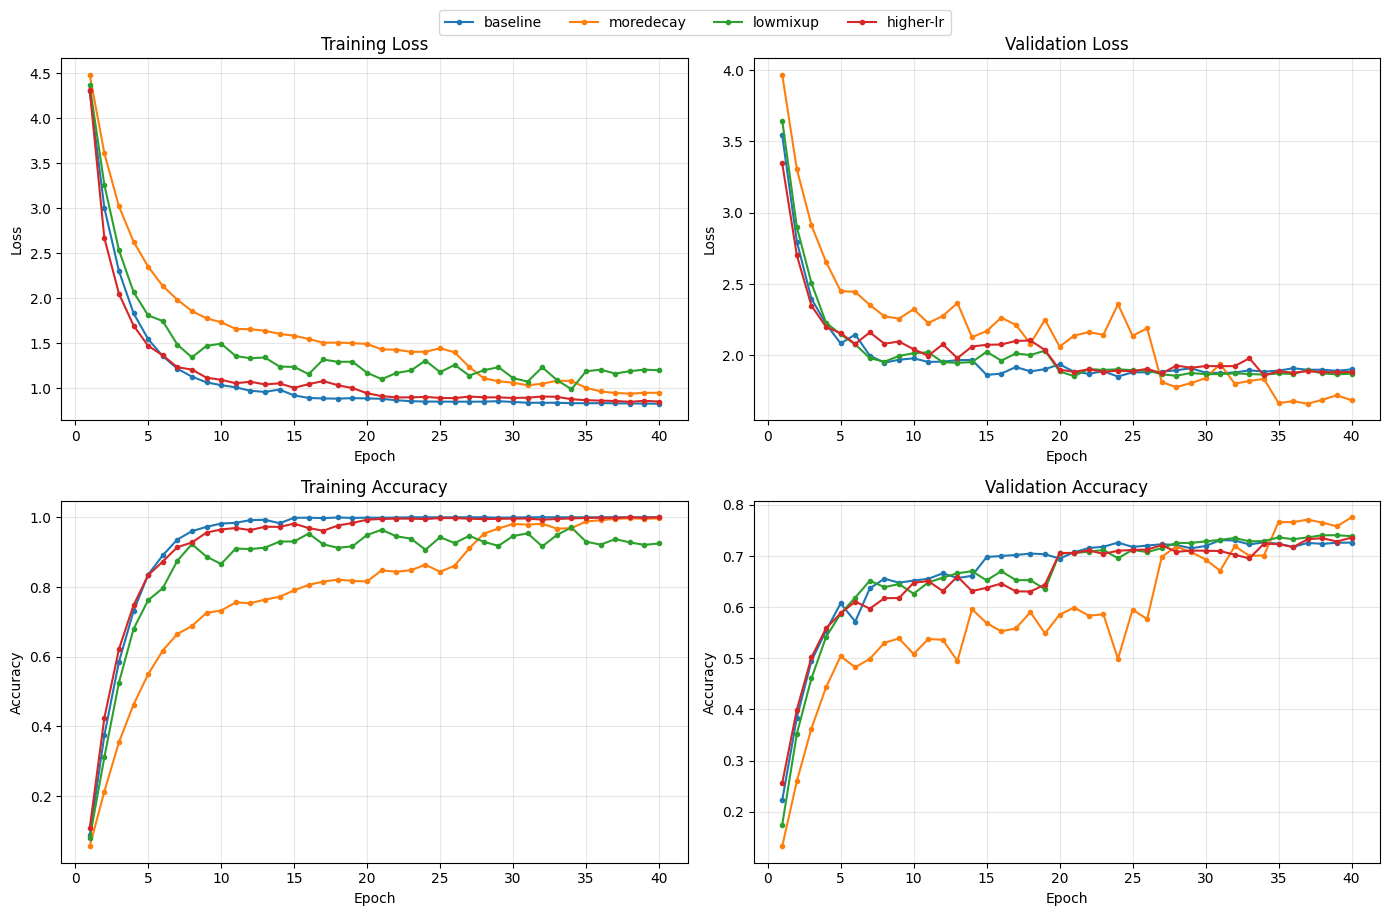

In [15]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(ft_results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in ft_results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(ft_results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

### actual training

In [ ]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=False)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

Total parameters: 11,227,812
epoch 1/50 loss=4.8661 accuracy=0.0117 val_loss=19.9168 val_accuracy=0.0084 time=123.9s eta=101.2min
epoch 2/50 loss=4.6645 accuracy=0.0094 val_loss=4.6190 val_accuracy=0.0174 time=123.9s eta=99.1min
epoch 3/50 loss=4.5838 accuracy=0.0171 val_loss=4.5274 val_accuracy=0.0213 time=121.6s eta=96.5min
epoch 4/50 loss=4.5114 accuracy=0.0225 val_loss=4.6919 val_accuracy=0.0114 time=119.9s eta=93.8min
epoch 5/50 loss=4.4544 accuracy=0.0310 val_loss=5.1398 val_accuracy=0.0093 time=119.8s eta=91.4min
epoch 6/50 loss=4.4343 accuracy=0.0289 val_loss=4.7457 val_accuracy=0.0156 time=119.6s eta=89.1min
epoch 7/50 loss=4.2900 accuracy=0.0432 val_loss=4.4931 val_accuracy=0.0270 time=119.8s eta=86.9min
epoch 8/50 loss=4.1709 accuracy=0.0513 val_loss=4.4404 val_accuracy=0.0309 time=120.6s eta=84.8min
epoch 9/50 loss=4.1087 accuracy=0.0630 val_loss=4.9914 val_accuracy=0.0144 time=120.5s eta=82.7min
epoch 10/50 loss=3.9797 accuracy=0.0807 val_loss=10.0948 val_accuracy=0.0171 t

ValueError: too many values to unpack (expected 3)

Total parameters: 11,227,812
epoch 1/50 loss=4.8661 accuracy=0.0117 val_loss=19.9168 val_accuracy=0.0084 time=121.9s eta=99.5min
epoch 2/50 loss=4.6645 accuracy=0.0094 val_loss=4.6190 val_accuracy=0.0174 time=119.2s eta=96.4min
epoch 3/50 loss=4.5838 accuracy=0.0171 val_loss=4.5274 val_accuracy=0.0213 time=120.7s eta=94.5min
epoch 4/50 loss=4.5114 accuracy=0.0225 val_loss=4.6919 val_accuracy=0.0114 time=120.1s eta=92.4min
epoch 5/50 loss=4.4544 accuracy=0.0310 val_loss=5.1398 val_accuracy=0.0093 time=120.2s eta=90.3min
epoch 6/50 loss=4.4343 accuracy=0.0289 val_loss=4.7457 val_accuracy=0.0156 time=119.9s eta=88.2min
epoch 7/50 loss=4.2900 accuracy=0.0432 val_loss=4.4931 val_accuracy=0.0270 time=121.8s eta=86.4min
epoch 8/50 loss=4.1709 accuracy=0.0513 val_loss=4.4404 val_accuracy=0.0309 time=119.3s eta=84.3min
epoch 9/50 loss=4.1087 accuracy=0.0630 val_loss=4.9914 val_accuracy=0.0144 time=119.5s eta=82.2min
epoch 10/50 loss=3.9797 accuracy=0.0807 val_loss=10.0948 val_accuracy=0.0171 ti

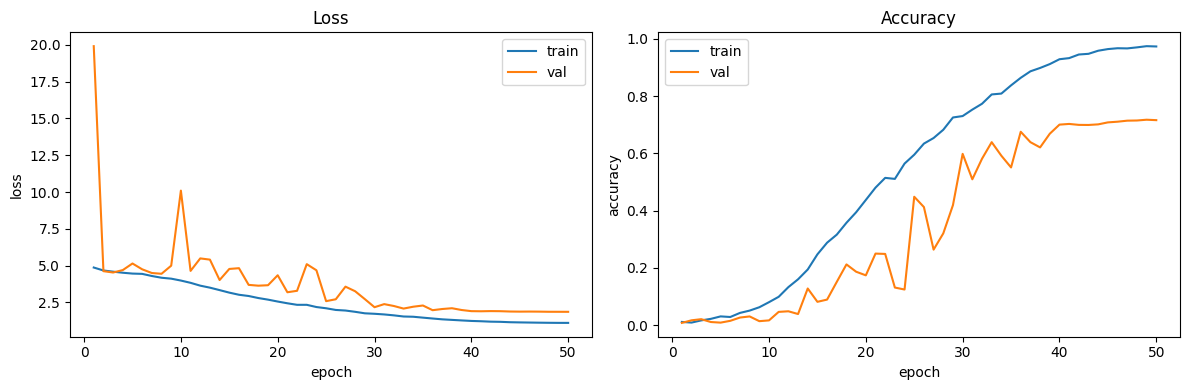

In [ ]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=False)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

Total parameters: 11,227,812
epoch 1/50 loss=4.9932 accuracy=0.0108 val_loss=24.5727 val_accuracy=0.0072 time=79.7s eta=65.1min
epoch 2/50 loss=4.7305 accuracy=0.0102 val_loss=11.3074 val_accuracy=0.0132 time=77.5s eta=62.9min
epoch 3/50 loss=4.6975 accuracy=0.0093 val_loss=4.7333 val_accuracy=0.0147 time=77.7s eta=61.3min
epoch 4/50 loss=4.6335 accuracy=0.0117 val_loss=4.6436 val_accuracy=0.0180 time=81.2s eta=60.6min
epoch 5/50 loss=4.5503 accuracy=0.0240 val_loss=4.5334 val_accuracy=0.0249 time=85.5s eta=60.2min
epoch 6/50 loss=4.4935 accuracy=0.0240 val_loss=4.4892 val_accuracy=0.0261 time=81.8s eta=59.1min
epoch 7/50 loss=4.4938 accuracy=0.0258 val_loss=4.5166 val_accuracy=0.0234 time=83.4s eta=58.0min
epoch 8/50 loss=4.4716 accuracy=0.0264 val_loss=7.8534 val_accuracy=0.0117 time=84.8s eta=57.0min
epoch 9/50 loss=4.5150 accuracy=0.0240 val_loss=4.6942 val_accuracy=0.0144 time=84.2s eta=55.9min
epoch 10/50 loss=4.4586 accuracy=0.0255 val_loss=4.5155 val_accuracy=0.0318 time=85.5s 

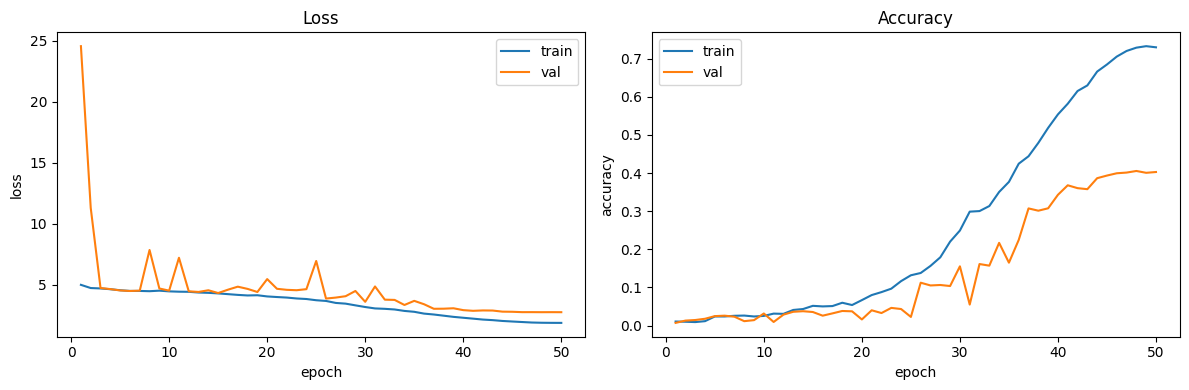

In [ ]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=True)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

### Ablations on the initial recipe

#### No augmentation

Total parameters: 11,227,812
Trainable parameters: 11,227,812
epoch 1/50 loss=4.0733 accuracy=0.1196 val_loss=3.4468 val_accuracy=0.2076 time=77.4s eta=63.2min
epoch 2/50 loss=3.2515 accuracy=0.2939 val_loss=3.1741 val_accuracy=0.2841 time=77.5s eta=61.9min
epoch 3/50 loss=2.5934 accuracy=0.5121 val_loss=3.0699 val_accuracy=0.3033 time=77.2s eta=60.6min
epoch 4/50 loss=2.5381 accuracy=0.5494 val_loss=3.9216 val_accuracy=0.1791 time=77.0s eta=59.2min
epoch 5/50 loss=2.5312 accuracy=0.5638 val_loss=3.0382 val_accuracy=0.3561 time=77.2s eta=57.9min
epoch 6/50 loss=2.3175 accuracy=0.6582 val_loss=2.7544 val_accuracy=0.4122 time=76.4s eta=56.5min
epoch 7/50 loss=1.9160 accuracy=0.7777 val_loss=2.4120 val_accuracy=0.5146 time=77.3s eta=55.3min
epoch 8/50 loss=2.0527 accuracy=0.7490 val_loss=2.5155 val_accuracy=0.5224 time=77.1s eta=54.0min
epoch 9/50 loss=1.8974 accuracy=0.7946 val_loss=2.4231 val_accuracy=0.5200 time=77.4s eta=52.7min
epoch 10/50 loss=1.6266 accuracy=0.8563 val_loss=2.3724 

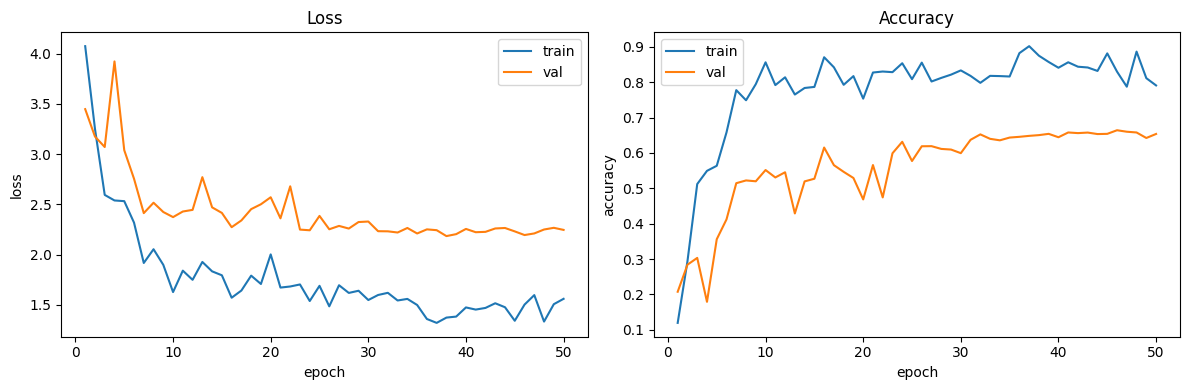

In [37]:
config = FinetuneConfig(
    epochs=50,
    lr_backbone=0.001,
    lr_head=0.001,
    weight_decay=1e-4,
    scheduler="ReduceLROnPlateau",
    label_smoothing=0.1,
    mixup_alpha=0.4,
    train_transform=T.Compose([
        T.Resize((256, 256)),
        T.ToTensor(),
    ])
)

resnet = build_resnet()
model, history, losses, accuracies = run_ft_experiment(
    resnet,
    config,
    name='resnet-noaugment'
)
plot_results(history)

Even in this case we can see that little data augmentation like 10 degrees rotation and horizontal flips do have a strong effect, both in keeping train/validation performance close and on the upper ceiling of validation performance. By the end of the experiment this network got a lower accuracy by 11.31%, going as low as 65.52%, which would not have met the target

#### No mixup

Total parameters: 11,227,812
Trainable parameters: 11,227,812
epoch 1/50 loss=3.9707 accuracy=0.1296 val_loss=4.5782 val_accuracy=0.0642 time=80.3s eta=65.5min
epoch 2/50 loss=2.8006 accuracy=0.3728 val_loss=3.0675 val_accuracy=0.2820 time=80.0s eta=64.1min
epoch 3/50 loss=2.3518 accuracy=0.4919 val_loss=2.7124 val_accuracy=0.3762 time=79.3s eta=62.6min
epoch 4/50 loss=2.0086 accuracy=0.6089 val_loss=2.7077 val_accuracy=0.3756 time=78.6s eta=61.0min
epoch 5/50 loss=1.8070 accuracy=0.6860 val_loss=2.4675 val_accuracy=0.4458 time=78.4s eta=59.5min
epoch 6/50 loss=1.6065 accuracy=0.7591 val_loss=2.3801 val_accuracy=0.5104 time=76.6s eta=57.8min
epoch 7/50 loss=1.4871 accuracy=0.8110 val_loss=2.2775 val_accuracy=0.5467 time=76.2s eta=56.2min
epoch 8/50 loss=1.4547 accuracy=0.8188 val_loss=2.3685 val_accuracy=0.5269 time=77.9s eta=54.9min
epoch 9/50 loss=1.3219 accuracy=0.8752 val_loss=2.2948 val_accuracy=0.5443 time=79.5s eta=53.7min
epoch 10/50 loss=1.2795 accuracy=0.8896 val_loss=2.2570 

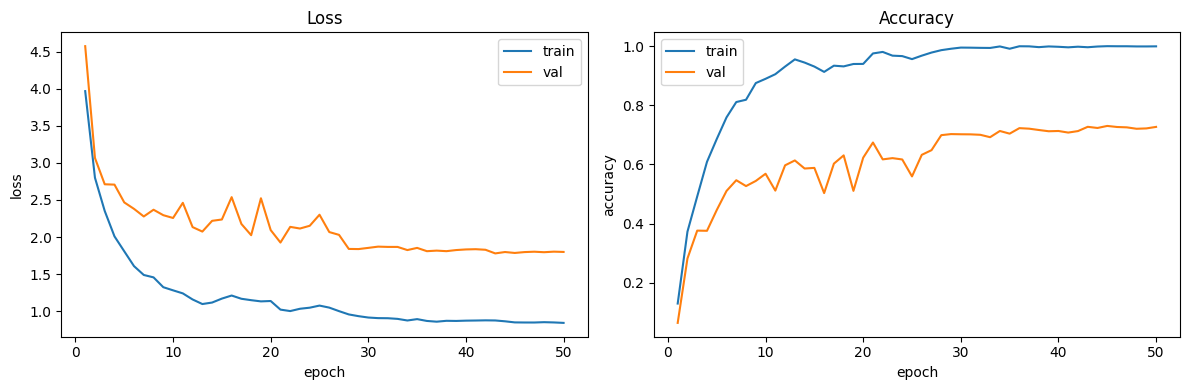

In [38]:
config = FinetuneConfig(
    epochs=50,
    lr_backbone=0.001,
    lr_head=0.001,
    weight_decay=1e-4,
    scheduler="ReduceLROnPlateau",
    label_smoothing=0.1,
    mixup_alpha=0.0,
    train_transform=T.Compose([
        T.Resize((256, 256)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ToTensor(),
    ])
)

resnet = build_resnet()
model, history, losses, accuracies = run_ft_experiment(
    resnet,
    config,
    name='resnet-nomixup'
)
plot_results(history)

Also here we case an effect of mixup. The final test accuracy drops by 4.38%, but we can also see a much bigger gap between training and validation performance, bigger than the one observed when removing data augmentation, with the training accuracy getting very close to 100%, while the validation one plateaus around 70%

#### No decay

Total parameters: 11,227,812
Trainable parameters: 11,227,812
epoch 1/50 loss=4.1513 accuracy=0.0985 val_loss=3.7894 val_accuracy=0.1350 time=79.2s eta=64.7min
epoch 2/50 loss=3.2788 accuracy=0.2721 val_loss=3.2187 val_accuracy=0.2460 time=79.8s eta=63.6min
epoch 3/50 loss=3.0418 accuracy=0.3649 val_loss=3.3203 val_accuracy=0.2442 time=79.4s eta=62.2min
epoch 4/50 loss=2.8704 accuracy=0.4315 val_loss=2.8022 val_accuracy=0.3675 time=78.5s eta=60.7min
epoch 5/50 loss=2.6887 accuracy=0.4936 val_loss=3.0155 val_accuracy=0.3153 time=78.9s eta=59.4min
epoch 6/50 loss=2.4982 accuracy=0.5590 val_loss=2.6039 val_accuracy=0.4362 time=78.4s eta=58.0min
epoch 7/50 loss=2.3044 accuracy=0.6188 val_loss=2.9649 val_accuracy=0.3411 time=79.1s eta=56.6min
epoch 8/50 loss=2.5446 accuracy=0.5603 val_loss=2.3895 val_accuracy=0.5170 time=79.0s eta=55.3min
epoch 9/50 loss=2.4523 accuracy=0.5946 val_loss=2.1794 val_accuracy=0.5794 time=78.6s eta=54.0min
epoch 10/50 loss=2.2781 accuracy=0.6506 val_loss=2.3178 

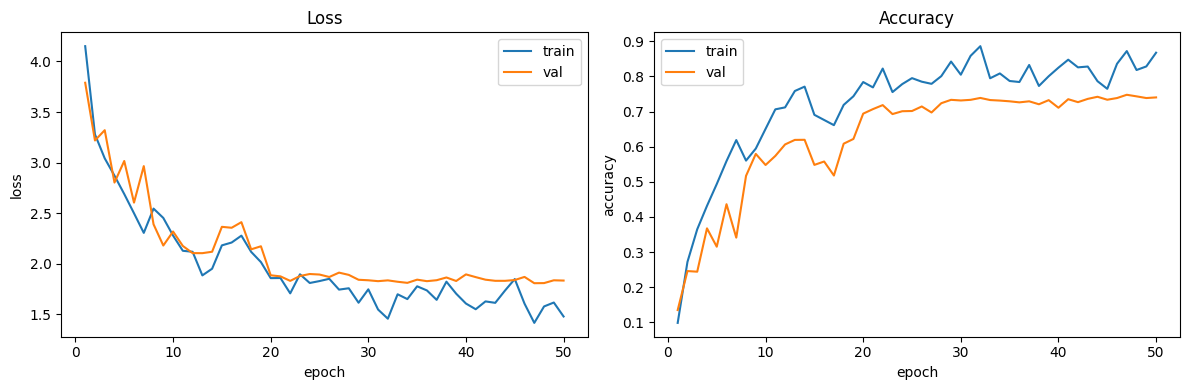

In [35]:
config = FinetuneConfig(
    epochs=50,
    lr_backbone=0.001,
    lr_head=0.001,
    weight_decay=0.0,
    scheduler="ReduceLROnPlateau",
    label_smoothing=0.1,
    mixup_alpha=0.4,
    train_transform=T.Compose([
        T.Resize((256, 256)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ToTensor(),
    ])
)

resnet = build_resnet()
model, history, losses, accuracies = run_ft_experiment(
    resnet,
    config,
    name='resnet-nodecay'
)
plot_results(history)

Removing weight decay from this recipe does not move the needle significantly. Final performance does drop by 2.46%, the smallest performance gain, and there's no evident effect on the generalization capability of the model, as training and validation performance stay quite close throughout training. We attribute this to the fact that 0.0001 is too low of a value to have a significant effect on this finetuning run

### Final implementation